In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# train test split
from sklearn.model_selection import train_test_split

In [3]:
# impute missing values
from sklearn.impute import SimpleImputer # mean, median, most_frequent (mode), constant
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # regresi
from sklearn.impute import KNNImputer # regresi KKN

In [4]:
# encoding
from sklearn.preprocessing import OneHotEncoder
from category_encoders import OrdinalEncoder, BinaryEncoder

In [5]:
# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler 

In [6]:
# column transformer & pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [7]:
# metric
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, make_scorer

In [8]:
# evaluation metrics
from sklearn.metrics import precision_score, make_scorer

In [9]:
# cross validation
from sklearn.model_selection import cross_val_score

In [10]:
# algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [11]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [12]:
# Polynomial feature
from sklearn.preprocessing import PolynomialFeatures

In [13]:
# ensemble
from sklearn.ensemble import VotingClassifier, StackingClassifier, VotingRegressor

Anda bekerja sebagai data scientist di sebuah hotel. Anda diminta untuk membuat model untuk memprediksi apakah seorang pelanggan akan membatalkan reservasi pemesanan kamar atau tidak. 

- Dataset:  `hotel_bookings.csv`

- Target: `is_canceled`

In [14]:
# Set max columns
pd.set_option('display.max_columns', None)

## **1. Business Problem: Hotel Cancellation Risk Prediction**

### Problem Overview

* **Target Variable**: `Cancellation` - Klasifikasi biner yang menunjukkan apakah pengunjung akan membatalkan pemesanan kamar mereka.

* **Class Distribution**: Dataset tidak seimbang dengan sekitar 28% kelas positif (pengunjung yang membatalkan pemesanan)
### Cost-Benefit Analysis

| Kenyataannya \ Prediksi | Kenyataan tidak dibatalkan **(0)** | Kenyataan dibatalkan **(1)**|
|-------------------|-----------------|-------------------|
| **Prediksi tidak Dibatalkan (0)** | **True Negative (TN)**<br><br>Cost : **0**<br><br>Dampak : <br><br>• Operasional normal<br><br>• Kepuasan tamu terjaga <br><br>• Revenue stabil | **False Negative (FN)**<br><br><span style="color:red">Cost: **-105 euro**</span><br><br>Dampak : <br><br>• Kamar kosong <br><br>• Kehilangan pendapatan (loss revenue)<br><br>• biaya pembersihan kamar sia-sia |
| **Prediksi dibatalkan (1)** | **False Positive (FP)**<br><br><span style="color:red">Cost: **-300 euro**</span><br><br>Dampak jika melakukan overbooking : <br><br>• Kekurangan kamar <br><br>• Reputasi hotel jadi jelek <br><br>• Harus bayar kompensasi ke tamu dan memindahkan tamu ke hotel lain<br><br>• Tamu kecewa jika kamar yang diberi dibawah tipe yang dipesan|**True Positive (TP)**<br><br> Cost : **0**<br><br> Dampak :<br><br>• Kamar kosong bisa dijual ke tamu lain<br><br>• Bisa overbooking <br><br>• biaya komisi ke agent dan biaya porsi makan bisa berkurang|

### Cost Ratio

**Rasio Biaya FP/FN**: 
300/105 = 2,85x - Salah memprediksi pembatalan (yang menyebabkan kelebihan pemesanan ketika penumpang datang) kurang lebih tiga kali lebih mahal daripada melewatkan pembatalan yang sebenarnya

**Strategis**: 

- Asimetri biaya yang ekstrem menuntut prediksi yang konservatif 
- Hotel kita melakukan overbooking artinya langsung menjual kamar ke orang lain yang diprediksi dibatalkan
- kita tidak ingin reputasi hotel jadi jelek (precision) tapi kita juga tidak ingin kamar kosong (recall) sehingga mempertimbangkan keduanya
- Namun lebih baik kamar kosong sesekali daripada menghadapi situasi reputasi hotel yang tercoret

### Evaluation Metric Selection

Mengingat konteks spesifik kita:

* **Data Tidak Seimbang**: Dengan hanya 28% kelas positif, akurasi akan menyesatkan karena akan selalu memprediksi "tidak ada pembatalan"

* **Pertimbangan Biaya**: Rasio biaya FP/FN yang dramatis (3:1) membuat false positive jauh lebih mahal dibandingkan false negative

* **Metrik yang Dipilih**: **F-beta** adalah metrik optimal untuk skenario ini karena kita mementingkan kedua metrik antara recall dan precision

### Formula


$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

$$F_\beta = \frac{1 + \beta^2}{\frac{\beta^2}{\text{Recall}} + \frac{1}{\text{Precision}}}$$

untuk **F-0.5 Score, β = 0.5**

Keterangan:
- **Presisi** = TP / (TP + FP) - Proporsi pengunjung yang diprediksi akan membatalkan pemesanan dan benar-benar membatalkan pemesanan

- **Recall** = TP / (TP + FN) - Proporsi pelanggan yang benar-benar membatalkan pemesanan dan teridentifikasi dengan tepat

- **β = 0.5** berarti precision diberi bobot **2x** lebih penting daripada recall

### **Referensi & Acuan Penentuan Nilai Cost:**

- Median ADR = 99 euro/malam
- Komponen FN Cost:
    1. Lost Revenue (utama):
    = ADR × (1 - kemungkinan re-sell last minute)
    = €99 × (1 - 0.05)     ← hanya 5% bisa re-sell mendadak
    = €99 × 0.95
    ≈ €94

    2. Biaya Operasional Kamar Tetap:
    (housekeeping, utilities, dll)
    ≈ 5-10% dari ADR
    = €99 × 0.10 = €9.9 ≈ €10

    Referensi:
    📊 STR Global Hotel Report (2017) "Fixed operating cost per room: 8-12% of ADR", www.str.com

    `Total FN Cost: €94 + €10 = €104 ≈ €105`

- Komponen FP Cost:
    1. Walking Cost (Relokasi Tamu):
    - 1 malam hotel setara/lebih tinggi: €99 - €150
    - Transport ke hotel lain: €15 - €30
    Referensi:
    📊 Cornell Hospitality Report (2015) "The Cost of Overbooking", www.chr.cornell.edu
        → Average walking cost: $150-$200 (≈€130-€180)

    2. Kompensasi/Voucher kepada Tamu:
    - Cash compensation: €50 - €100
    - Meal voucher: €20 - €50
    Referensi:
    📊 American Hotel & Lodging Association (AHLA) "Best Practices in Overbooking Management", www.ahla.com

    3. Reputasi & Review Damage:
    📄 Ye, Q., Law, R., & Gu, B. (2009)
        "The Impact of Online Reviews on Hotel Revenue"
        International Journal of Hospitality Management
        DOI: 10.1016/j.ijhm.2008.09.011
        → 1 negative review = loss €100-€200 future revenue
        → Estimasi per kejadian: €50-€100

    `Total FP Cost: Walking (€150) + Kompensasi (€75) + Reputasi (€75) = €300`


## **2. Data Loading**

In [15]:
# Load dataset
df = pd.read_csv("C:/Users/HP/Documents/FINPRO DS/data_bersih_hotel.csv")
df.head()

,Unnamed: 0,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86940 entries, 0 to 86939
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      86940 non-null  int64  
 1   hotel                           86940 non-null  object 
 2   is_canceled                     86940 non-null  int64  
 3   lead_time                       86940 non-null  int64  
 4   arrival_date_year               86940 non-null  int64  
 5   arrival_date_month              86940 non-null  object 
 6   arrival_date_week_number        86940 non-null  int64  
 7   arrival_date_day_of_month       86940 non-null  int64  
 8   stays_in_weekend_nights         86940 non-null  int64  
 9   stays_in_week_nights            86940 non-null  int64  
 10  adults                          86940 non-null  int64  
 11  children                        86940 non-null  float64
 12  babies                          

In [17]:
df["adr"].median()   # kita asumsikan harga perkamar sekitar $98

98.4

In [18]:
df['children'] = df['children'].astype(int)

## **3. ML Data Preparation**

Pada bagian ini, kita mempersiapkan data untuk pemodelan pembelajaran mesin:

- Mendefinisikan variabel target (`is_canceled`) dan memisahkan kolom fitur numerik dan kategorikal

- Memeriksa outlier pada fitur numerik dan menilai multikolinearitas melalui heatmap

### **3.1 Outlier / Multicolinearity Check**

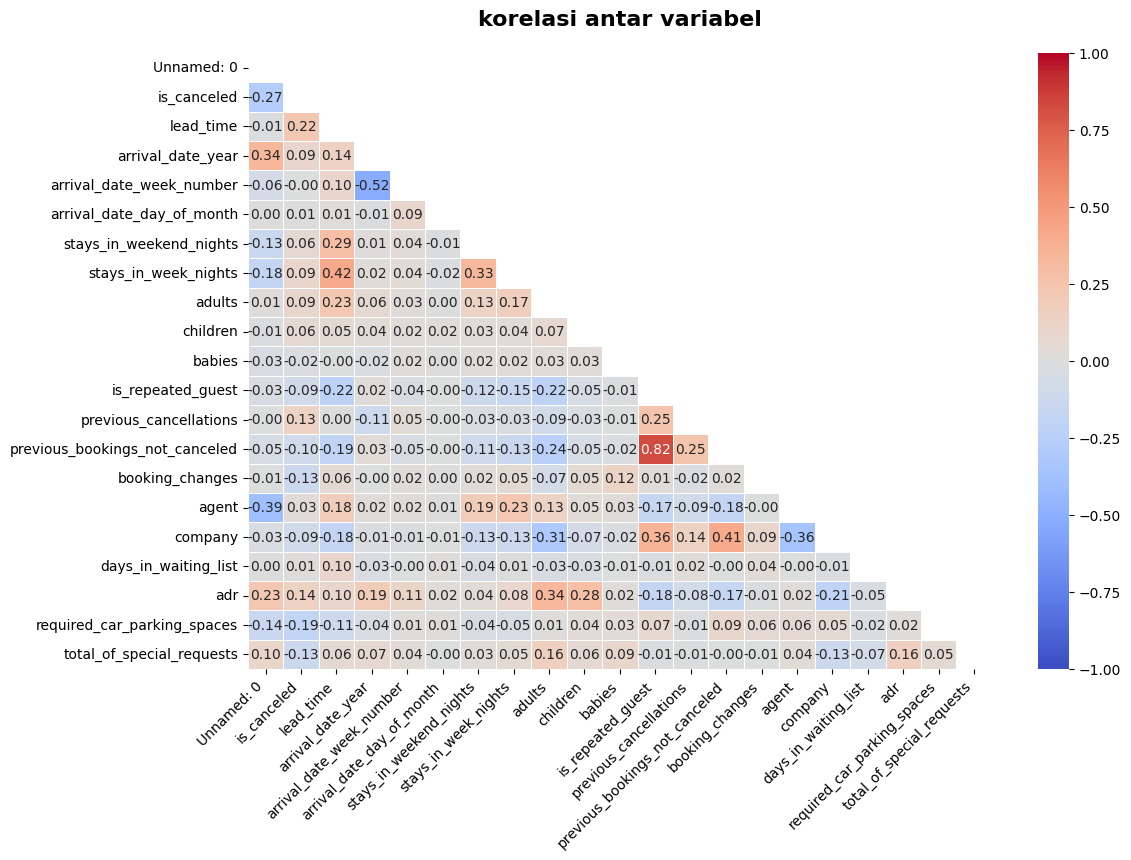

In [19]:
# plot berbentuk heatmap

# 1. Hitung matriks korelasi terlebih dahulu agar kode lebih bersih
corr_matrix = df.corr(numeric_only=True, method="spearman")

# 2. Buat mask untuk menyembunyikan bagian segitiga atas (opsional tapi bagus)
mask_for_corr = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Setting ukuran figure (diperbesar sedikit agar angka tidak bertumpuk)
plt.figure(figsize=(12, 8))

# 4. Gambar Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # MENAMPILKAN ANGKA KORELASI
    fmt=".2f",           # FORMAT 2 ANGKA DI BELAKANG KOMA
    mask=mask_for_corr, 
    vmin=-1, vmax=1, 
    center=0, 
    cmap='coolwarm', 
    linewidths=.5,       # MEMBERI GARIS PEMISAH ANTAR KOTAK
    annot_kws={"size": 10} # MENGATUR UKURAN FONT ANGKA
)

plt.title("korelasi antar variabel", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotasi label X agar lebih rapi
plt.show()

**Insight:**
- `is_repeated_guest` dan `previous_bookings_not_canceled` memiliki nilai korelasi yang tinggi yaitu **0.82** ini menunjukkan bahwa kedua variabel membawa informasi yang mirip, seorang tamu yang berstatus `is_repeated_guest` (tamu berulang) pasti memiliki jumlah `previous_bookings_not_canceled` (pemesanan sebelumnya yang tidak dibatalkan) lebih dari nol.

- `arrival_date_year` dan `arrival_date_week_number` memiliki nilai korelasi negatif yaitu **-0.52** ini menunjukkan adanya tumpang tindih informasi.

**Recommendation:**
- hapus kolom `is_repeated_guest` dan kolom `Unnamed: 0` terbawa dari file asli

In [20]:
df.drop(columns=["is_repeated_guest", "Unnamed: 0"], inplace= True)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [21]:
target_col = "is_canceled"
numerical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "number").columns
categorical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "object").columns

C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183

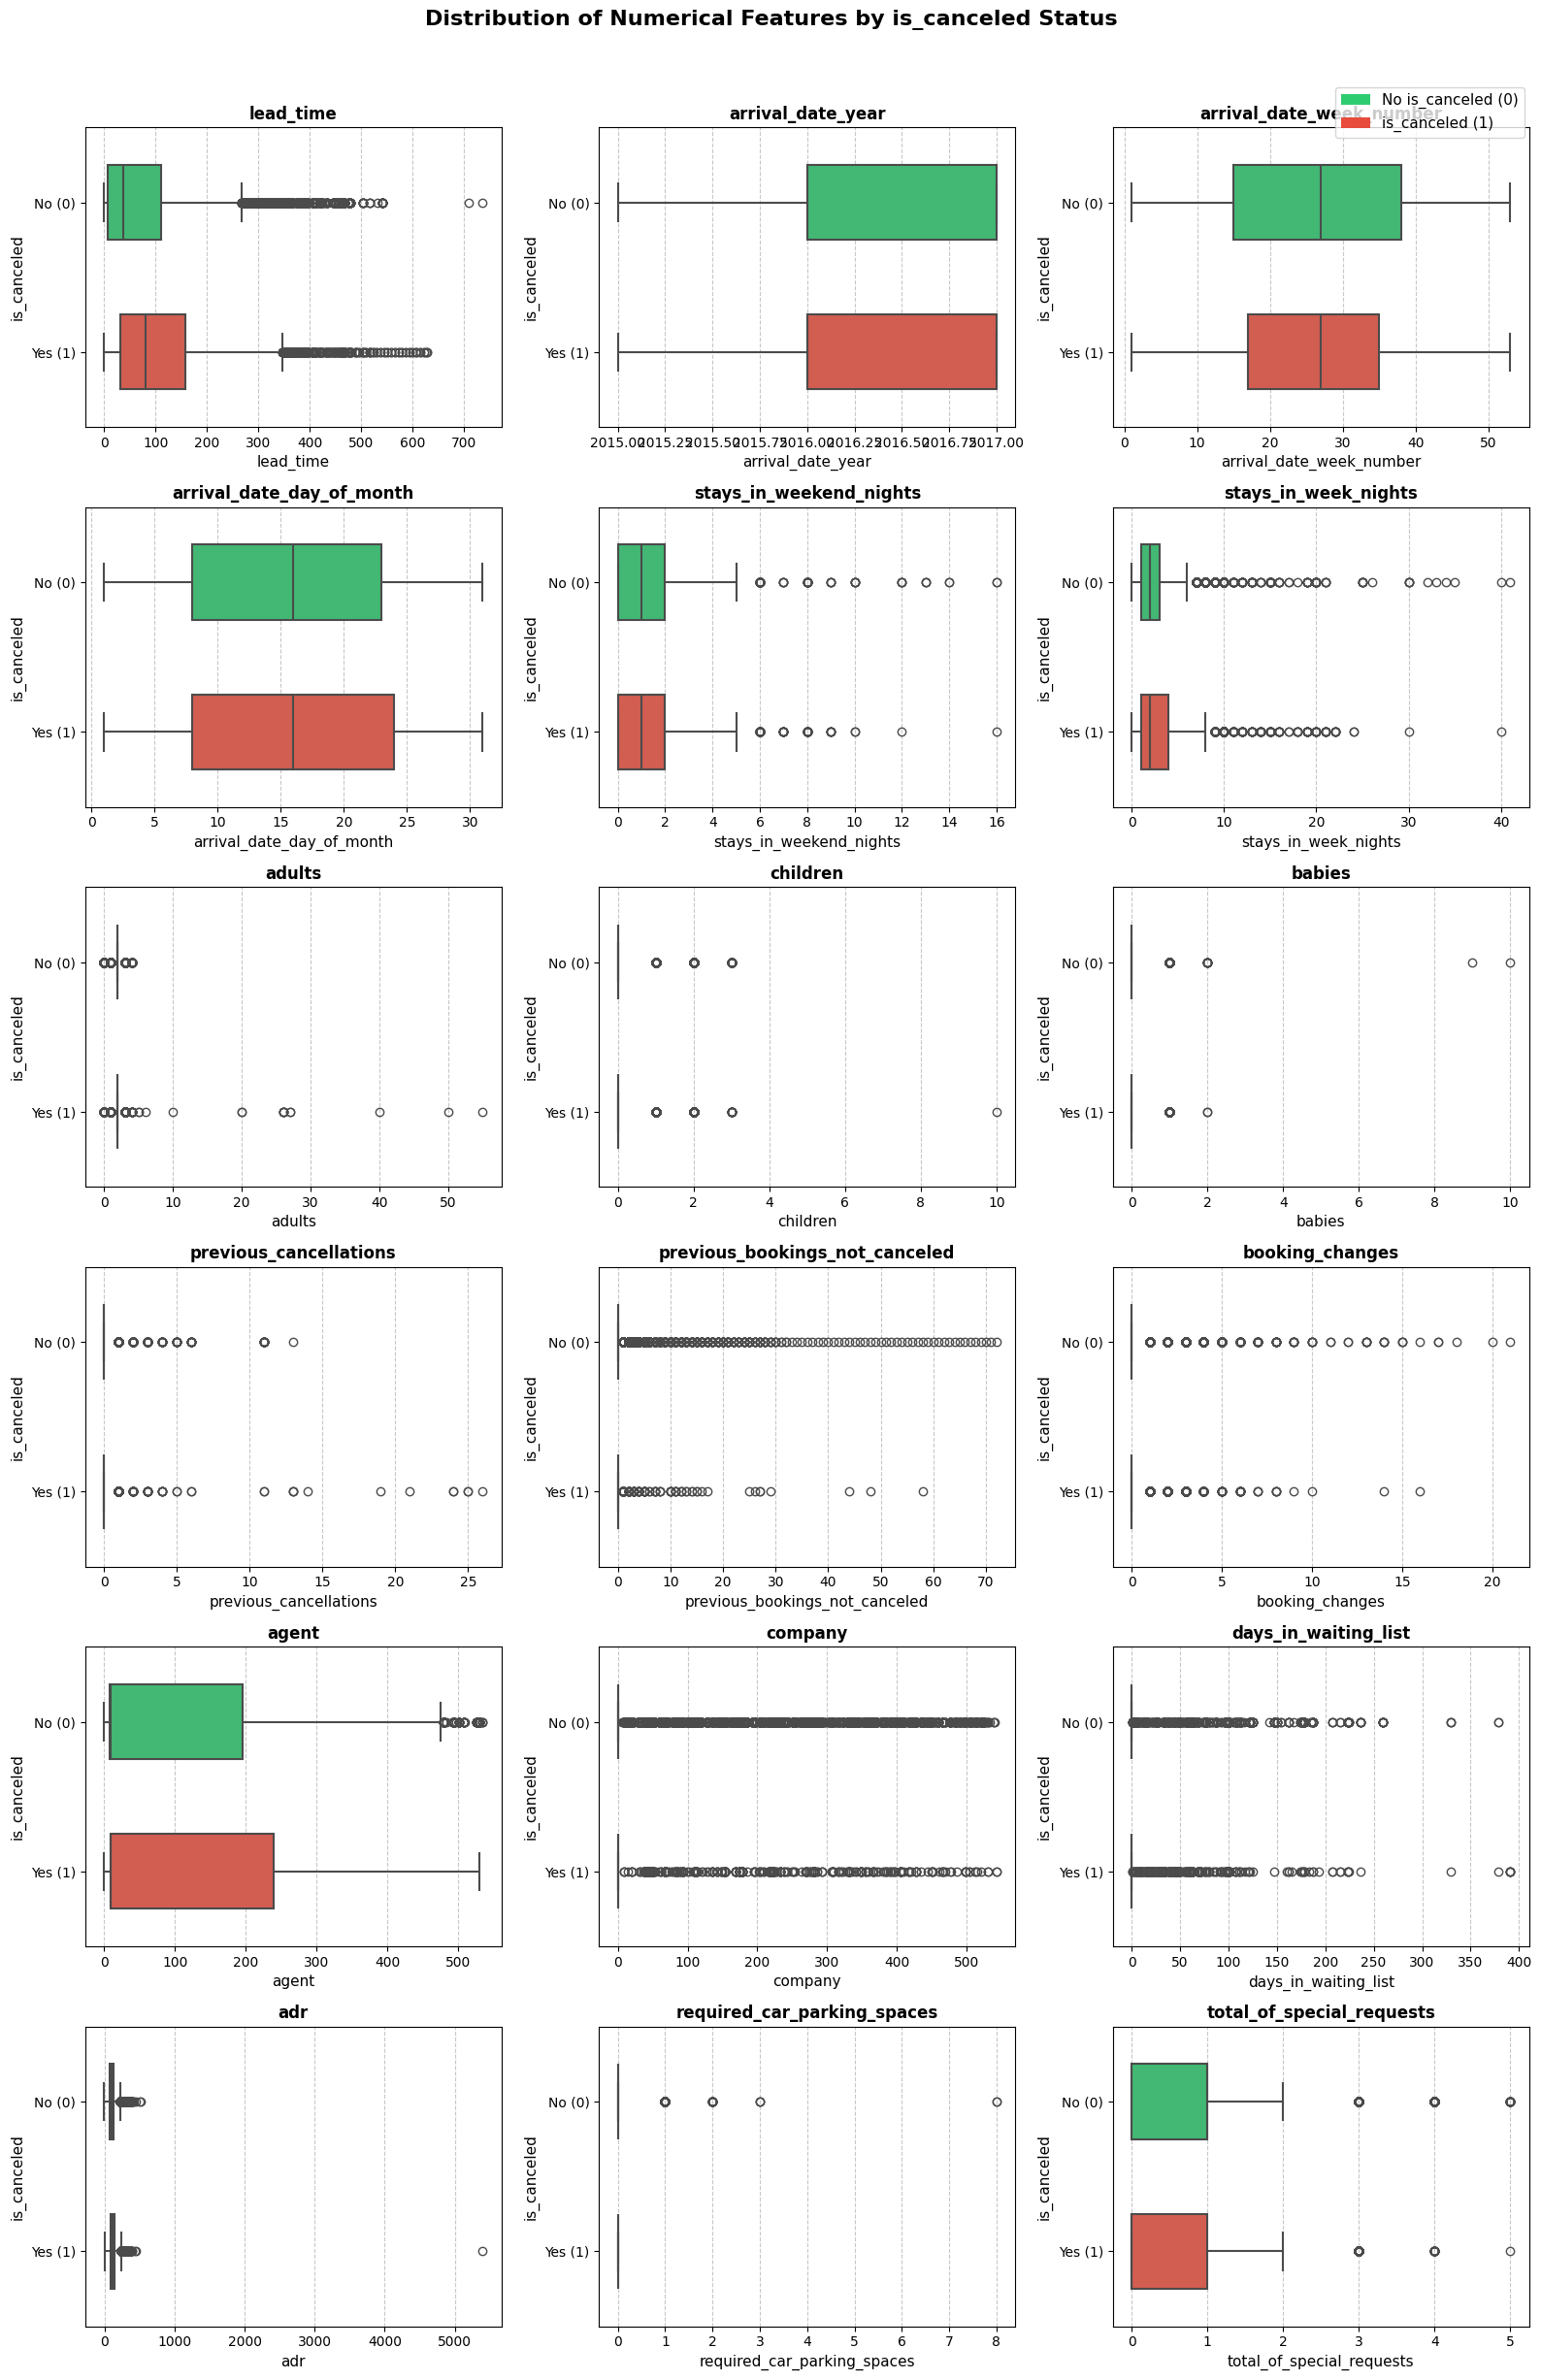

In [22]:
# Calculate grid dimensions (3 columns, wrap to new row)
n_cols = 3
n_rows = int(np.ceil(len(numerical_feature_cols) / n_cols))

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))

# Flatten axes for easy iteration (handle single row case)
if n_rows == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Color palette for hue
palette = {0: '#2ecc71', 1: '#e74c3c'}  # Green for 0, Red for 1
# Or use: palette = sns.color_palette("husl", 2)

# Create horizontal boxplot for each numerical column
for idx, col in enumerate(numerical_feature_cols):
    ax = axes[idx]
    
    # Create horizontal boxplot with hue
    sns.boxplot(
        data=df,
        y='is_canceled',       # Categorical on y-axis
        x=col,             # Numerical on x-axis
        hue='is_canceled',
        palette=palette,
        ax=ax,
        width=0.5,
        linewidth=1.5,
        orient='h',        # Horizontal orientation
        legend=False       # Avoid duplicate legends
    )
    
    # Set labels and title
    ax.set_ylabel('is_canceled', fontsize=11)
    ax.set_xlabel(col, fontsize=11)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    
    # Customize y-tick labels
    ax.set_yticklabels(['No (0)', 'Yes (1)'])
    
    # Add grid for better readability
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

# Hide unused subplots (if features not divisible by 3)
for idx in range(len(numerical_feature_cols), len(axes)):
    axes[idx].set_visible(False)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='No is_canceled (0)'),
    Patch(facecolor='#e74c3c', label='is_canceled (1)')
]
fig.legend(
    handles=legend_elements, 
    loc='upper right', 
    bbox_to_anchor=(0.99, 0.99),
    fontsize=11
)

plt.suptitle('Distribution of Numerical Features by is_canceled Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**
- kolom `adr` (average Daily Rate) memiliki outlier dengan nilai sangat tinggi yaitu > 4000 dan terdapat nilai `adr`= 0.

- kolom `babies` memiliki outlier di angka 9 dan 10

- kolom `children` memiliki outlier di angka 10

- jika ada kombinasi `adults` + `children` + `babies` = 0 adalah data yang tidak valid karena pemesanan hotel tanpa tamu adalah hal yang tidak mungkin.

**Recommendation:**
- hapus baris data pada kolom `adr`> 4000 dan `adr`= 0

- menghapus baris dengan jumlah `babies` yang tidak realistis diatas 2 dan baris `children` diatas 4

- buat kolom baru `total tamu` jika sama dengan 0 hapus baris tersebut

In [23]:
adr_hapus = (df['adr'] > 4000) | (df['adr'] == 0)
df = df[~adr_hapus]

In [24]:
babies_hapus = (df['babies'] > 2)
df = df[~babies_hapus]

In [25]:
children_hapus = (df['children'] > 4)
df = df[~children_hapus]

- Membuat kolom baru `total_tamu`

In [26]:
# Membuat kolom baru 'total_tamu' dengan menjumlahkan tiga kolom
df['total_tamu'] = df['adults'] + df['children'] + df['babies']

df_sorted = df.sort_values(by='total_tamu', ascending=True)
df_sorted[['adults', 'children', 'babies', 'total_tamu']].head(10)

,adults,children,babies,total_tamu
72336,0,0,0,0
72493,0,0,0,0
69508,0,0,0,0
74518,0,0,0,0
73836,0,0,0,0
66325,0,0,0,0
26046,0,0,0,0
71801,0,0,0,0
59039,0,0,0,0
71803,0,0,0,0


hapus baris yang memiliki `total_tamu`= 0

In [27]:
# hanya baris 'total_tamu' lebih besar dari 0
df = df[df['total_tamu'] > 0]

In [28]:
df.drop(columns='total_tamu', inplace=True)

- Buat kolom baru total_menginap

In [29]:
# df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

kolom ID `agent` dan `company` diubah menjadi angka binner, jika menggunakan agent dan company maka bernilai 1 pada kolom `is_by_agent` dan `is_by_company`

In [30]:
df['is_by_agent'] = (df['agent'] != 0).astype(int)
df['is_by_company'] = (df['company'] != 0).astype(int)

In [31]:
df.drop(columns=['agent', 'company'], inplace=True)

In [32]:
df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)   # korelasi fitur numeric terhadap target

is_canceled                       1.000000
lead_time                         0.181555
is_by_agent                       0.128918
adr                               0.121609
arrival_date_year                 0.086635
adults                            0.080302
stays_in_week_nights              0.079181
children                          0.066536
stays_in_weekend_nights           0.056012
previous_cancellations            0.052759
arrival_date_day_of_month         0.005082
days_in_waiting_list              0.004795
arrival_date_week_number          0.002343
babies                           -0.021205
previous_bookings_not_canceled   -0.048391
is_by_company                    -0.091475
booking_changes                  -0.092799
total_of_special_requests        -0.123689
required_car_parking_spaces      -0.185986
Name: is_canceled, dtype: float64

- korelasi hubungan antara target (`is_canceled`) dengan fitur `arrival_date_day_of_month` & `arrival_date_week_number` sangat lemah sehingga akan dihapus

In [33]:
df.drop(columns=['arrival_date_day_of_month', 'arrival_date_week_number'], inplace=True)

- `reservation_status_date` adalah tanggal terakhir status booking berubah, secara tidak langsung memberi tahu masa depan ke model sehingga harus kita hapus

In [34]:
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

- `assigned_room_type` adalah kamar yang benar-benar diberikan setelah booking karena kondisi hotel overbooking, secara tidak langsung bisa membuat kebocoran data dari masa depan sehingga akan di hapus

In [35]:
df.drop(columns=["assigned_room_type"], inplace=True)

In [36]:
numerical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "number").columns

C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['No (0)', 'Yes (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7748\1091572183

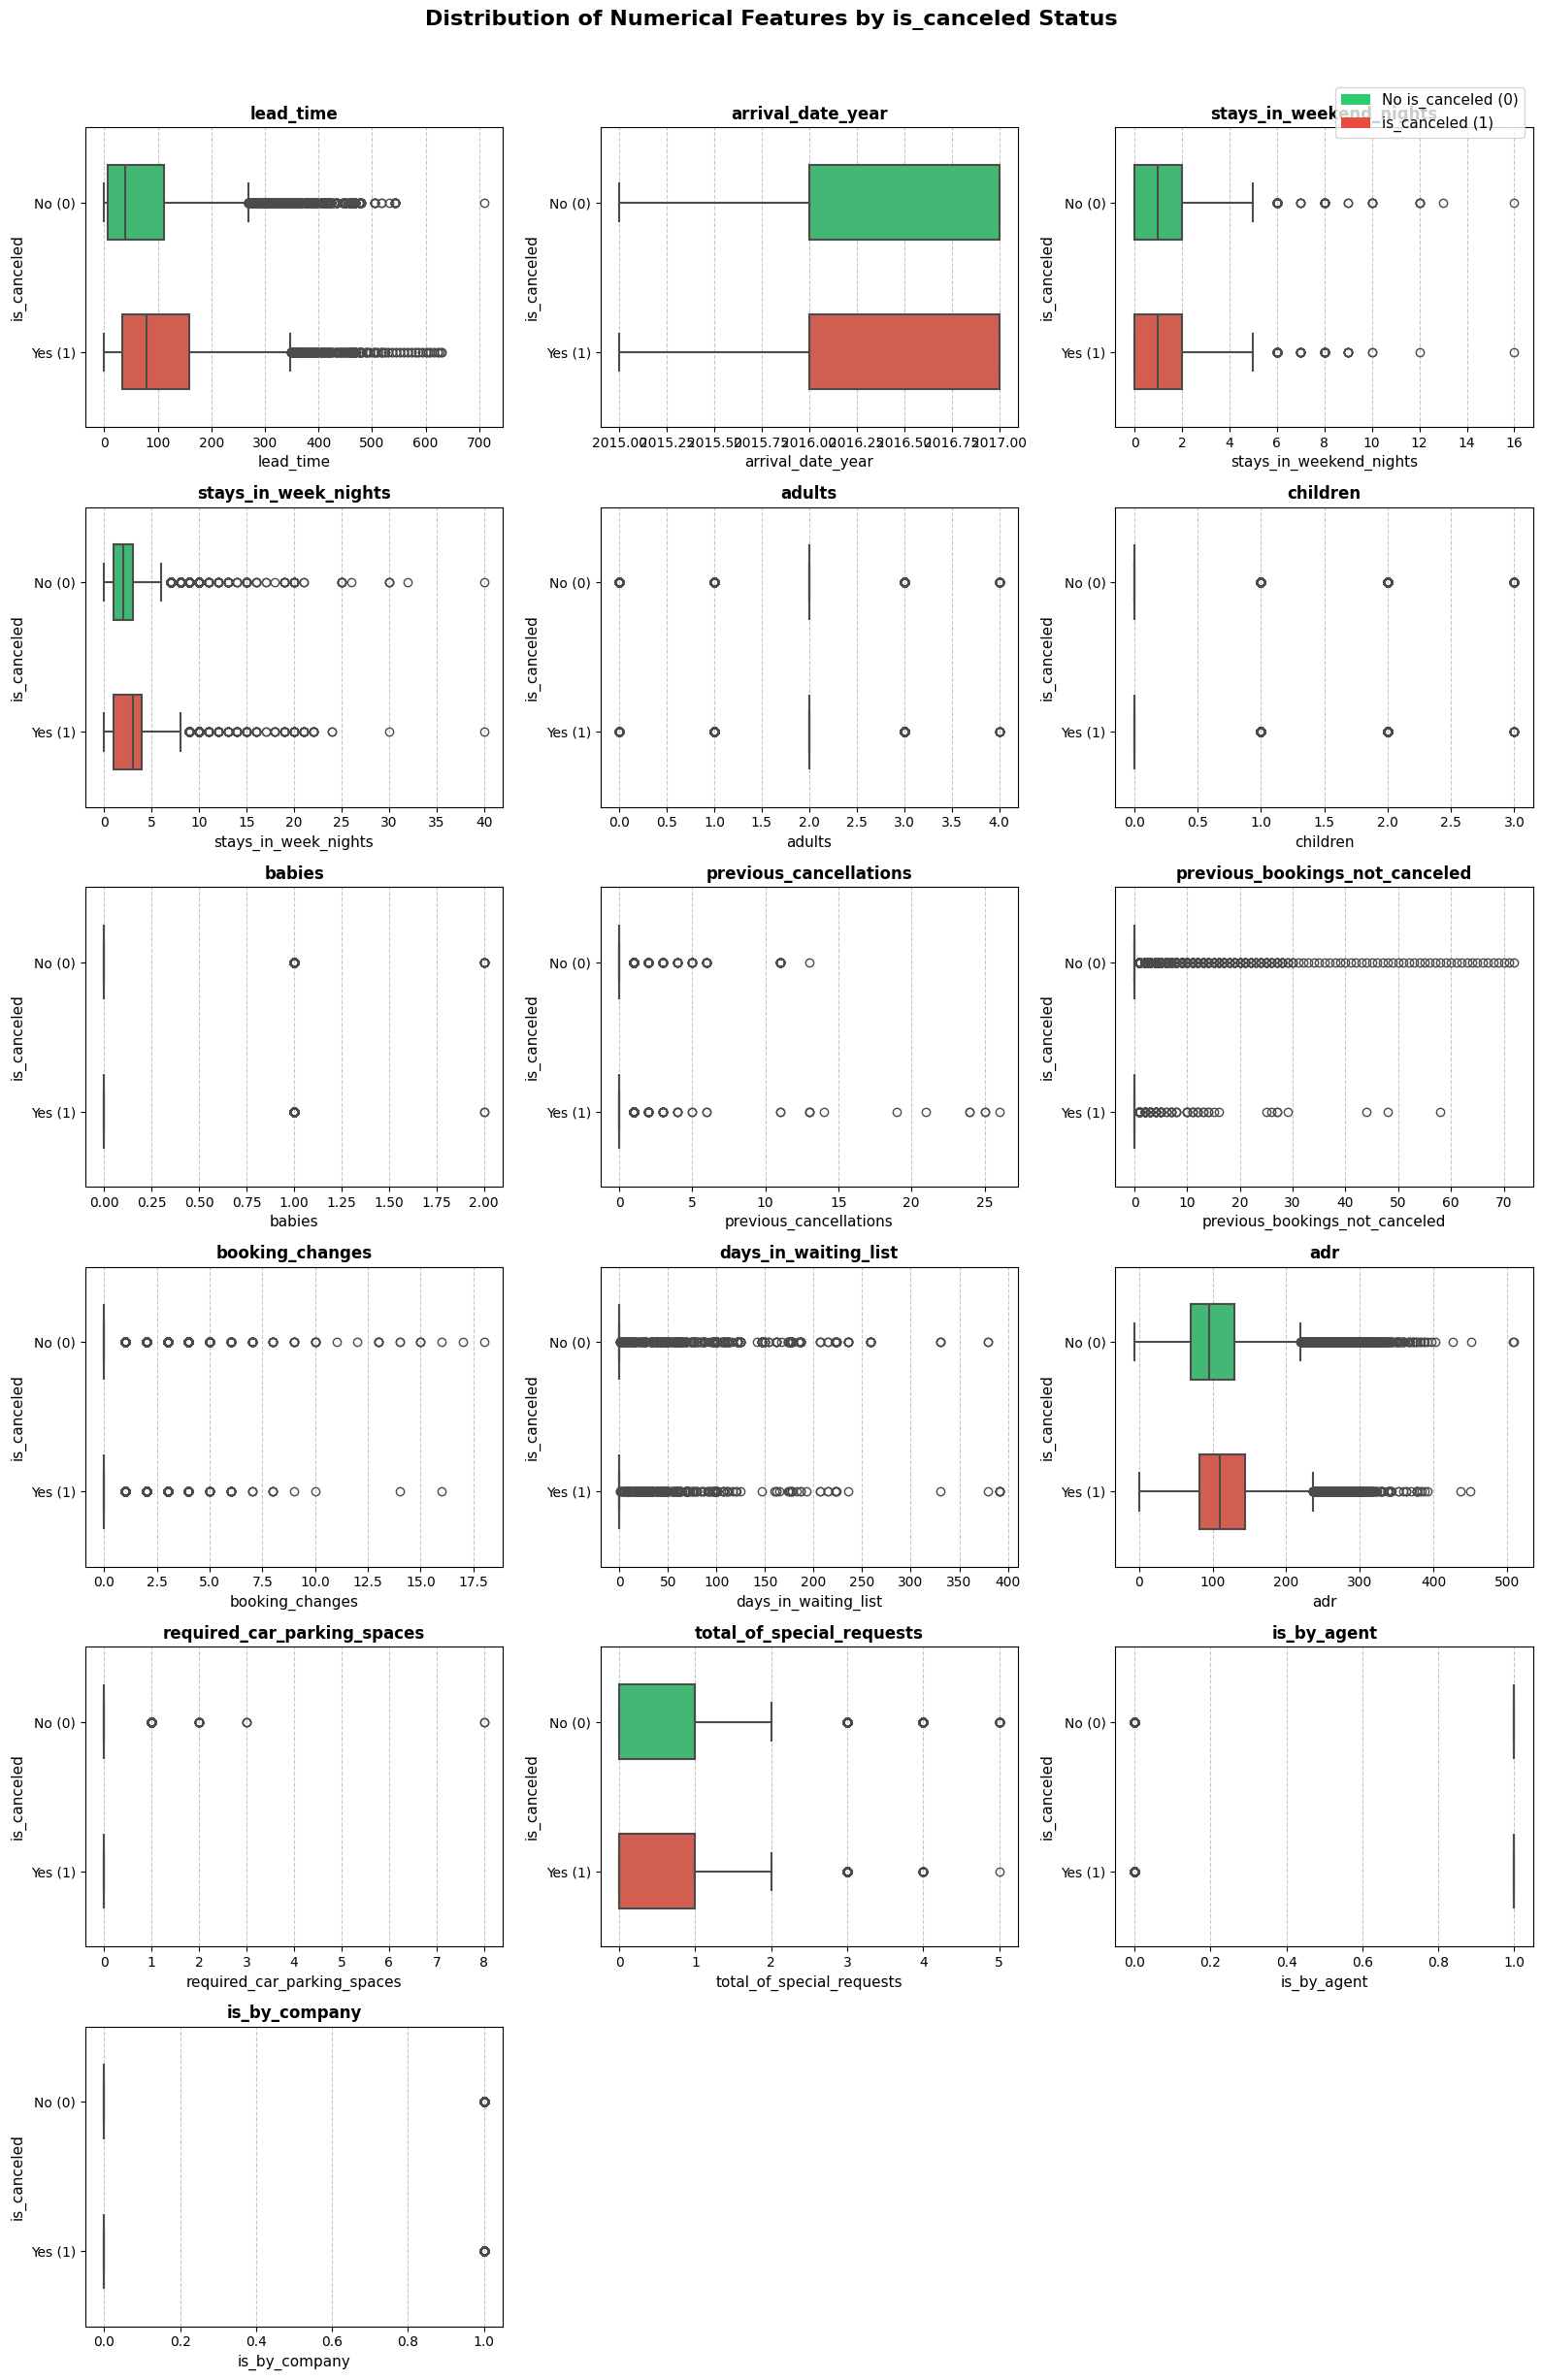

In [37]:
# Calculate grid dimensions (3 columns, wrap to new row)
n_cols = 3
n_rows = int(np.ceil(len(numerical_feature_cols) / n_cols))

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))

# Flatten axes for easy iteration (handle single row case)
if n_rows == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Color palette for hue
palette = {0: '#2ecc71', 1: '#e74c3c'}  # Green for 0, Red for 1
# Or use: palette = sns.color_palette("husl", 2)

# Create horizontal boxplot for each numerical column
for idx, col in enumerate(numerical_feature_cols):
    ax = axes[idx]
    
    # Create horizontal boxplot with hue
    sns.boxplot(
        data=df,
        y='is_canceled',       # Categorical on y-axis
        x=col,             # Numerical on x-axis
        hue='is_canceled',
        palette=palette,
        ax=ax,
        width=0.5,
        linewidth=1.5,
        orient='h',        # Horizontal orientation
        legend=False       # Avoid duplicate legends
    )
    
    # Set labels and title
    ax.set_ylabel('is_canceled', fontsize=11)
    ax.set_xlabel(col, fontsize=11)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    
    # Customize y-tick labels
    ax.set_yticklabels(['No (0)', 'Yes (1)'])
    
    # Add grid for better readability
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

# Hide unused subplots (if features not divisible by 3)
for idx in range(len(numerical_feature_cols), len(axes)):
    axes[idx].set_visible(False)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='No is_canceled (0)'),
    Patch(facecolor='#e74c3c', label='is_canceled (1)')
]
fig.legend(
    handles=legend_elements, 
    loc='upper right', 
    bbox_to_anchor=(0.99, 0.99),
    fontsize=11
)

plt.suptitle('Distribution of Numerical Features by is_canceled Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85143 entries, 2 to 86939
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           85143 non-null  object 
 1   is_canceled                     85143 non-null  int64  
 2   lead_time                       85143 non-null  int64  
 3   arrival_date_year               85143 non-null  int64  
 4   arrival_date_month              85143 non-null  object 
 5   stays_in_weekend_nights         85143 non-null  int64  
 6   stays_in_week_nights            85143 non-null  int64  
 7   adults                          85143 non-null  int64  
 8   children                        85143 non-null  int32  
 9   babies                          85143 non-null  int64  
 10  meal                            85143 non-null  object 
 11  country                         85143 non-null  object 
 12  market_segment                  85143

### **2.3. EDA for ML**

In [39]:
# Menghitung rata-rata 'lead_time' untuk yang batal dan tidak batal
hubungan_numerik = df.groupby(target_col)["lead_time"].mean()

print(f"Rata-rata {"lead_time"} berdasarkan {target_col}:")
print(hubungan_numerik)

Rata-rata lead_time berdasarkan is_canceled:
is_canceled
0     71.297581
1    106.078849
Name: lead_time, dtype: float64


In [40]:
# Menghitung rata-rata 'arrival_date_year' untuk yang batal dan tidak batal
hubungan_numerik = df.groupby(target_col)["arrival_date_year"].mean()

print(f"Rata-rata {"arrival_date_year"} berdasarkan {target_col}:")
print(hubungan_numerik)

Rata-rata arrival_date_year berdasarkan is_canceled:
is_canceled
0    2016.180296
1    2016.312371
Name: arrival_date_year, dtype: float64


In [41]:
# Buat tabel silang
crosstab = pd.crosstab(df['hotel'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe hotel
crosstab_pct = pd.crosstab(df['hotel'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled       0      1    All
hotel                            
City Hotel    36378  15933  52311
Resort Hotel  24960   7872  32832
All           61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled           0          1
hotel                             
City Hotel    69.541779  30.458221
Resort Hotel  76.023392  23.976608


**Insight `Hotel`:**

City Hotel memiliki tingkat pembatalan sebesar 30.46%, lebih tinggi dibanding Resort Hotel sebesar 23.98%. Hal ini menunjukkan bahwa karakteristik pelanggan City Hotel cenderung lebih fleksibel dan memiliki risiko pembatalan lebih tinggi.

city hotel lebih tinggi bisa jadi karena:
- Booking lebih fleksibel (business travel)
- Lead time pendek sehingga lebih mudah berubah
- Lebih banyak booking via agent/OTA

sedangkan alasan resort lebih rendah bisa jadi karena:
- Liburan lebih terencana
- Booking jauh-jauh hari
- Lebih “committed”

In [42]:
# Buat tabel silang
crosstab = pd.crosstab(df['arrival_date_month'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['arrival_date_month'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled             0      1    All
arrival_date_month                     
April                5360   2390   7750
August               7465   3609  11074
December             3532   1362   4894
February             4508   1395   5903
January              3492   1025   4517
July                 6690   3176   9866
June                 5295   2343   7638
March                5498   1817   7315
May                  5769   2428   8197
November             3763   1042   4805
October              5071   1605   6676
September            4895   1613   6508
All                 61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled                 0          1
arrival_date_month                      
April               69.161290  30.838710
August              67.410150  32.589850
December            72.170004  27.829996
February            76.367949  23.632051
January             77.307948  22.692052
July                67.808636  32.191364
June        

**Insight `arrival_date_month`:**

Tingkat pembatalan tertinggi terjadi pada bulan Agustus (~32.6%), sedangkan terendah pada bulan November (~21.7%). Hal ini menunjukkan adanya pola musiman di mana periode peak season (juli-agustus) memiliki risiko pembatalan yang lebih tinggi.

peak season lebih tinggi bisa jadi karena:
- Banyak booking jauh hari (lead time tinggi)
- Lebih banyak perubahan rencana (liburan)
- OTA / agent dominan

sedangkan alasan low season lebih rendah bisa jadi karena:
- Booking lebih sedikit tapi lebih pasti
- Lebih banyak business / necessity travel”

In [43]:
# Buat tabel silang
crosstab = pd.crosstab(df['meal'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe meal
crosstab_pct = pd.crosstab(df['meal'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled      0      1    All
meal                            
BB           48303  17871  66174
FB             246     98    344
HB            6476   2431   8907
SC            5934   3325   9259
Undefined      379     80    459
All          61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled          0          1
meal                             
BB           72.993925  27.006075
FB           71.511628  28.488372
HB           72.706860  27.293140
SC           64.088994  35.911006
Undefined    82.570806  17.429194


**Insight `meal`:**

Tingkat pembatalan tertinggi terjadi pada tipe Self Catering (35.9%), menunjukkan bahwa pelanggan tanpa paket makan memiliki fleksibilitas lebih tinggi untuk membatalkan pemesanan. Sebaliknya, tipe Undefined memiliki tingkat pembatalan terendah (17.4%).

- `country`

In [44]:
# Buat tabel silang
crosstab = pd.crosstab(df['country'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['country'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled      0      1    All
country                         
ABW              2      0      2
AGO            142    193    335
AIA              1      0      1
ALB              9      2     11
AND              2      5      7
...            ...    ...    ...
VNM              6      2      8
ZAF             49     29     78
ZMB              1      1      2
ZWE              2      2      4
All          61338  23805  85143

[178 rows x 3 columns]

--- Persentase Pembatalan (%) ---
is_canceled           0           1
country                            
ABW          100.000000    0.000000
AGO           42.388060   57.611940
AIA          100.000000    0.000000
ALB           81.818182   18.181818
AND           28.571429   71.428571
...                 ...         ...
VGB            0.000000  100.000000
VNM           75.000000   25.000000
ZAF           62.820513   37.179487
ZMB           50.000000   50.000000
ZWE           50.000000   50.000000

[177 rows x 2 colu

- `market_segment`

In [45]:
# Buat tabel silang
crosstab = pd.crosstab(df['market_segment'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled         0      1    All
market_segment                     
Aviation          178     44    222
Complementary      57      5     62
Corporate        3467    493   3960
Direct           9720   1697  11417
Groups           3402   1315   4717
Offline TA/TO   11569   2026  13595
Online TA       32945  18225  51170
All             61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled             0          1
market_segment                      
Aviation        80.180180  19.819820
Complementary   91.935484   8.064516
Corporate       87.550505  12.449495
Direct          85.136200  14.863800
Groups          72.122112  27.877888
Offline TA/TO   85.097462  14.902538
Online TA       64.383428  35.616572


- `distribution_channel`

In [46]:
# Buat tabel silang
crosstab = pd.crosstab(df['distribution_channel'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['distribution_channel'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled               0      1    All
distribution_channel                     
Corporate              4116    616   4732
Direct                10246   1820  12066
GDS                     141     36    177
TA/TO                 46834  21333  68167
Undefined                 1      0      1
All                   61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled                    0          1
distribution_channel                       
Corporate              86.982249  13.017751
Direct                 84.916294  15.083706
GDS                    79.661017  20.338983
TA/TO                  68.704799  31.295201
Undefined             100.000000   0.000000


- `reserved_room_type`

In [47]:
# Buat tabel silang
crosstab = pd.crosstab(df['reserved_room_type'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['reserved_room_type'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled             0      1    All
reserved_room_type                     
A                   40385  14526  54911
B                     652    311    963
C                     602    294    896
D                   11953   5220  17173
E                    4268   1634   5902
F                    1900    845   2745
G                    1227    730   1957
H                     347    243    590
L                       4      2      6
All                 61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled                 0          1
reserved_room_type                      
A                   73.546284  26.453716
B                   67.705088  32.294912
C                   67.187500  32.812500
D                   69.603447  30.396553
E                   72.314470  27.685530
F                   69.216758  30.783242
G                   62.698007  37.301993
H                   58.813559  41.186441
L                   66.666667  33.333333


- `customer_type`

In [48]:
# Buat tabel silang
crosstab = pd.crosstab(df['customer_type'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['customer_type'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled          0      1    All
customer_type                       
Contract          2604    510   3114
Group              468     37    505
Transient        48700  21508  70208
Transient-Party   9566   1750  11316
All              61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled              0          1
customer_type                        
Contract         83.622351  16.377649
Group            92.673267   7.326733
Transient        69.365314  30.634686
Transient-Party  84.535171  15.464829


- `deposit_type`

In [49]:
# Buat tabel silang
crosstab = pd.crosstab(df['deposit_type'], df['is_canceled'], margins=True)

# Buat tabel persentase pembatalan per tipe deposit
crosstab_pct = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100

print("--- Jumlah Data Asli ---")
print(crosstab)
print("\n--- Persentase Pembatalan (%) ---")
print(crosstab_pct)

--- Jumlah Data Asli ---
is_canceled       0      1    All
deposit_type                     
No Deposit    61202  22798  84000
Non Refund       55    981   1036
Refundable       81     26    107
All           61338  23805  85143

--- Persentase Pembatalan (%) ---
is_canceled           0          1
deposit_type                      
No Deposit    72.859524  27.140476
Non Refund     5.308880  94.691120
Refundable    75.700935  24.299065


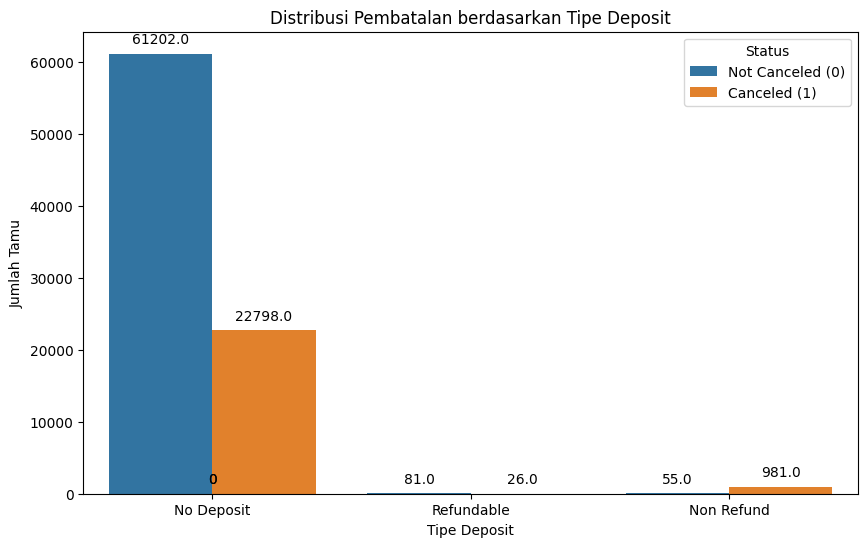

In [50]:
plt.figure(figsize=(10, 6))

# Visualisasi hubungan Deposit Type vs Cancellation
ax = sns.countplot(x='deposit_type', hue='is_canceled', data=df)

plt.title('Distribusi Pembatalan berdasarkan Tipe Deposit')
plt.xlabel('Tipe Deposit')
plt.ylabel('Jumlah Tamu')
plt.legend(title='Status', labels=['Not Canceled (0)', 'Canceled (1)'])

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### **3.2. Define Target and feature columns**

In [51]:
target_col = "is_canceled"
numerical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "number").columns
categorical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "object").columns

print("Target column:", target_col)
print()
print("Numerical feature columns:")
print(numerical_feature_cols)
print()
print("Categorical feature columns:")
print(categorical_feature_cols)

Target column: is_canceled

Numerical feature columns:
Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'is_by_agent', 'is_by_company'],
      dtype='object')

Categorical feature columns:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type',
       'customer_type'],
      dtype='object')


In [52]:
df[target_col].value_counts(normalize=True)

is_canceled
0    0.720412
1    0.279588
Name: proportion, dtype: float64

data pemesanan yang tidak dibatalkan ada 72% dan pemesanan yang dibatalkan ada 28%

## **4. Define X, y**

In [53]:
X = df.drop(columns=target_col)
y = df[target_col]

display(X.head(), y.head())

,hotel,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_by_agent,is_by_company
2,Resort Hotel,7,2015,July,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,A,0,No Deposit,0,Transient,75.0,0,0,0,0
3,Resort Hotel,13,2015,July,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,A,0,No Deposit,0,Transient,75.0,0,0,1,0
4,Resort Hotel,14,2015,July,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,A,0,No Deposit,0,Transient,98.0,0,1,1,0
5,Resort Hotel,0,2015,July,0,2,2,0,0,BB,PRT,Direct,Direct,0,0,C,0,No Deposit,0,Transient,107.0,0,0,0,0
6,Resort Hotel,9,2015,July,0,2,2,0,0,FB,PRT,Direct,Direct,0,0,C,0,No Deposit,0,Transient,103.0,0,1,1,0


2    0
3    0
4    0
5    0
6    0
Name: is_canceled, dtype: int64

## **5. Train-Test Split**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.20,
                                                    random_state = 0,
                                                    stratify = y)

In [55]:
df[categorical_feature_cols].nunique()

hotel                     2
arrival_date_month       12
meal                      5
country                 177
market_segment            7
distribution_channel      5
reserved_room_type        9
deposit_type              3
customer_type             4
dtype: int64

## **6. Preprocessing**

- **Fitur numerik** : hanya RobustScaler (tidak ada nilai yang hilang terdeteksi)

- `hotel`, `deposit_type`, `customer_type`: OneHotEncoding (hapus kategori pertama, abaikan kategori yang tidak dikenal)

- `arrival_date_month`, `country`, `market_segment`, `reserved_room_type`, `meal`, `distribution_channel`: BinaryEncoding untuk menangani kardinalitas tinggi secara efisien

In [56]:
onehot = OneHotEncoder(drop="first",
                       sparse_output=False,
                       handle_unknown="ignore" # mengabaikan kategori langka (anggap 0 semua)
                       )
onehot

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [57]:
onehot_cols = ['hotel', 'deposit_type', 'customer_type']
onehot_cols

['hotel', 'deposit_type', 'customer_type']

In [58]:
binary_cols = ['meal', 'distribution_channel',"market_segment","reserved_room_type","arrival_date_month", "country"]
binary_cols

['meal',
 'distribution_channel',
 'market_segment',
 'reserved_room_type',
 'arrival_date_month',
 'country']

In [59]:
robust_cols = numerical_feature_cols

**Column Transformer**

In [60]:
preprocess_transformer = ColumnTransformer([
    ("robust", RobustScaler(), robust_cols),
    ('onehot', OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), onehot_cols),
    ('binary', BinaryEncoder(handle_unknown="value"), binary_cols),
], remainder="passthrough")

preprocess_transformer.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'is_by_agent', 'is_by_company'],
      dtype='object')),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['hotel', 'deposit_type', 'customer_type']),
                                ('binary', BinaryEncoder(),
                                 ['meal', 'distribution_channel',
                                  'market_segment', 'reserved_room_type',
                                  'arrival_date_month', 'country'])])

In [61]:
preprocess_transformer.fit_transform(X_train, y_train)

,robust__lead_time,robust__arrival_date_year,robust__stays_in_weekend_nights,robust__stays_in_week_nights,robust__adults,robust__children,robust__babies,robust__previous_cancellations,robust__previous_bookings_not_canceled,robust__booking_changes,robust__days_in_waiting_list,robust__adr,robust__required_car_parking_spaces,robust__total_of_special_requests,robust__is_by_agent,robust__is_by_company,onehot__hotel_Resort Hotel,onehot__deposit_type_Non Refund,onehot__deposit_type_Refundable,onehot__customer_type_Group,onehot__customer_type_Transient,onehot__customer_type_Transient-Party,binary__meal_0,binary__meal_1,binary__meal_2,binary__distribution_channel_0,binary__distribution_channel_1,binary__distribution_channel_2,binary__market_segment_0,binary__market_segment_1,binary__market_segment_2,binary__reserved_room_type_0,binary__reserved_room_type_1,binary__reserved_room_type_2,binary__reserved_room_type_3,binary__arrival_date_month_0,binary__arrival_date_month_1,binary__arrival_date_month_2,binary__arrival_date_month_3,binary__country_0,binary__country_1,binary__country_2,binary__country_3,binary__country_4,binary__country_5,binary__country_6,binary__country_7
55734,0.191304,-1.0,0.5,-0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.647841,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1
78643,-0.339130,1.0,-0.5,-0.333333,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.093023,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
67746,-0.217391,0.0,0.5,0.333333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.110133,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,0
1259,0.330435,-1.0,1.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.502824,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1
26229,-0.391304,1.0,-0.5,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.079734,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72258,-0.321739,0.0,-0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.166113,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0
11752,1.382609,-1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.336379,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,1,1,0,0,0,0,1,1,0,1
66118,1.347826,0.0,-0.5,-0.333333,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.151163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1
147,0.434783,-1.0,0.5,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.249169,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,1,1


## **7. Model Selection with Cross Validation**

In [62]:
# Voting and Stacking
from sklearn.ensemble import VotingClassifier, StackingClassifier
# Bagging, RF, and Boosting
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

- **Define ensemble models**

In [63]:
list_base_estimator = [
    ("logreg", LogisticRegression()),
    ("knn", KNeighborsClassifier()),
    ("dtree", DecisionTreeClassifier())
]

## voting
votinghard = VotingClassifier(
    estimators = list_base_estimator,
    voting = "hard" # tipe voting --> "hard", "soft"
)

votingsoft = VotingClassifier(
    estimators = list_base_estimator,
    voting = "soft" # tipe voting --> "hard", "soft"
)

## stacking
stacking = StackingClassifier(
    estimators = list_base_estimator,
    final_estimator = LogisticRegression(random_state=0) # optional, default = Logistic
)

## bagging
bagging = BaggingClassifier(random_state=0)

## random forest
rf = RandomForestClassifier(random_state=0)

## boosting
adaboost = AdaBoostClassifier(random_state=0)
gboost = GradientBoostingClassifier(random_state=0)
xgboost = XGBClassifier(random_state=0)

- **Model Selection**

In [64]:
# Define basic models
logistic = LogisticRegression(random_state=0)
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=0)

list_model_name = ["logistic", "knn", "decision tree", "votinghard","votingsoft", "stacking", "bagging", "random forest", "adaboost","gboost","xgboost"]

list_model = [logistic, knn, dtree, votinghard, votingsoft, stacking, bagging, rf, adaboost, gboost, xgboost]

list_FB_all = [] 
list_FB_mean = []
list_FB_std = []

fbeta = make_scorer(fbeta_score, beta= 0.5)

for model in list_model:
    pipe_model = Pipeline(steps=[
        ("preprocess", preprocess_transformer),
        ("model", model)  
    ])

    pipe_model.fit(X_train, y_train)

    cv_score = cross_val_score(
        estimator = pipe_model,
        cv = 5,
        X = X_train,
        y = y_train,
        scoring = fbeta
    )

    # membulatkan semua FB dalam cv_score
    model_FB = np.round(cv_score, 2)

    # hitung rata2 dan standar deviasi
    FB_mean = np.mean(cv_score)
    FB_std = np.std(cv_score)

    list_FB_all.append(model_FB)
    list_FB_mean.append(FB_mean)
    list_FB_std.append(FB_std)


c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mode

In [65]:
df_cv = pd.DataFrame()
df_cv["model"] = list_model_name
df_cv["FB_all"] = list_FB_all
df_cv["FB_mean"] = list_FB_mean
df_cv["FB_std"] = list_FB_std

df_cv.sort_values(["FB_mean", "FB_std"], 
                  ascending=[False, True])

,model,FB_all,FB_mean,FB_std
7,random forest,"[0.72, 0.71, 0.7, 0.71, 0.72]",0.713082,0.004925
10,xgboost,"[0.72, 0.7, 0.7, 0.71, 0.71]",0.707931,0.005777
6,bagging,"[0.68, 0.67, 0.68, 0.69, 0.68]",0.679006,0.007889
5,stacking,"[0.67, 0.68, 0.67, 0.68, 0.68]",0.674021,0.005208
9,gboost,"[0.67, 0.68, 0.67, 0.67, 0.68]",0.673422,0.003035
3,votinghard,"[0.66, 0.67, 0.66, 0.68, 0.68]",0.671312,0.008174
4,votingsoft,"[0.64, 0.65, 0.64, 0.66, 0.66]",0.649731,0.007679
8,adaboost,"[0.63, 0.63, 0.63, 0.64, 0.63]",0.631452,0.004536
1,knn,"[0.62, 0.61, 0.6, 0.62, 0.61]",0.612868,0.007262
0,logistic,"[0.6, 0.62, 0.6, 0.62, 0.61]",0.610034,0.008631


- Random Forest mencapai skor rata-rata Fbeta-0.5 tertinggi di antara semua model dalam validasi silang yaitu 0.713082
- Diurutan kedua ada xgboost dengan skor rata-rata Fbeta-0.5 adalah 0.707931

Karena selisih nilai antara Random Forest dan xgboost tidak terlalu jauh dan proses tunning data xgboost tidak terlalu berat, kita bisa memeilih xgboost sebagai model kandidat terbaik untuk penyetelan hyperparameter lebih lanjut

### **random forest**

In [66]:
# ratio = 0.72/0.28
# scale_pos_weight = ratio

pipe_base = Pipeline(steps=[
    ("preprocess", preprocess_transformer),
    ("model", RandomForestClassifier(random_state=0, class_weight='balanced'))])

pipe_base

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
       'is_by_agent', 'is_by_company'],
      dtype='object')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel', 'deposit_type',
                                                   'customer_type']),
                                                 ('binary', BinaryEncoder(),
                                                  ['meal',
                                                   'distribution_channel',
                                                   'market_segment',
                                                   'reserved_room_type',
                                                   'arrival_date_month',
                                                   'country'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=0))])

In [67]:
pipe_base.fit(X_train, y_train)

y_train_base = pipe_base.predict(X_train)
y_test_base = pipe_base.predict(X_test)

fbeta_train_base = fbeta_score(y_train, y_train_base, beta= 0.5)
fbeta_test_base = fbeta_score(y_test, y_test_base, beta= 0.5)

print(f"fbeta Train = {fbeta_train_base:.2%}")
print(f"fbeta Test = {fbeta_test_base:.2%}")

fbeta Train = 99.22%
fbeta Test = 71.16%


Dari hasil di atas, terlihat bahwa model dasar kita mengalami overfitting. Kita akan meningkatkan performa dan mengurangi overfitting dengan **hyperparameter tuning**.

### **xgboost**

In [68]:
pipe_basexgb = Pipeline(steps=[
    ("preprocess", preprocess_transformer),
    ("model", XGBClassifier(random_state=0, scale_pos_weight=2.6))])

pipe_basexgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [69]:
pipe_basexgb.fit(X_train, y_train)

y_train_basexgb = pipe_basexgb.predict(X_train)
y_test_basexgb = pipe_basexgb.predict(X_test)

fbeta_train_basexgb = fbeta_score(y_train, y_train_basexgb, beta= 0.5)
fbeta_test_basexgb = fbeta_score(y_test, y_test_basexgb, beta= 0.5)

print(f"fbeta Train = {fbeta_train_basexgb:.2%}")
print(f"fbeta Test = {fbeta_test_basexgb:.2%}")

fbeta Train = 67.34%
fbeta Test = 62.86%


Dari hasil di atas, terlihat bahwa model dasar kita mengalami underfitting. Kita akan meningkatkan performa dengan **hyperparameter tuning**.

## **8. Hyperparameter Tuning**

**Tuning Random Forest**

- Tingkatkan `n_estimators` --> Lebih banyak averaging --> Mengurangi overfitting

- Tingkatkan `max_depth` --> Kedalaman yang lebih besar cenderung meningkatkan overfitting

- Tingkatkan `min_samples_leaf` --> Nilai yang lebih besar mengurangi overfitting

- Tingkatkan `min_samples_split` --> Nilai yang lebih besar mengurangi overfitting

- `class_weight` --> Penalti untuk kesalahan klasifikasi label kelas minoritas

**Tuning XGBoost**

- Tingkatkan `n_estimators` --> Jumlah pohon, lebih banyak averaging --> Mengurangi overfitting

- Tingkatkan `max_depth` --> Kedalaman maksimum setiap pohon keputusan, nilai yang lebih besar cenderung meningkatkan overfitting

- Tingkatkan `min_child_weight` --> Minimum jumlah data di setiap leaf node, nilai yang lebih kecil cenderung meningkatkan overfitting

- `scale_pos_weight` --> Mengatur BOBOT kelas positif (batal=1) untuk menangani CLASS IMBALANCe (Pengganti resampling!)

- `learning_rate` --> Mengatur SEBERAPA BESAR kontribusi setiap pohon baru terhadap prediksi akhir (Step size dalam gradient descent)

- `gamma` --> Minimum PENURUNAN LOSS yang diperlukan untuk melakukan split pada leaf node (Threshold untuk split)

- `subsample` --> Proporsi data training yang digunakan untuk membangun setiap pohon

- `colsample_bytree` --> PROPORSI FITUR (kolom) yang digunakan secara ACAK untuk membangun setiap pohon

- `reg_alpha` --> Regularisasi L1 (LASSO) pada bobot leaf → Mendorong bobot menjadi NOL (sparse model)

- `reg_lambda` --> Regularisasi L2 (Ridge) pada bobot leaf → Mendorong bobot menjadi KECIL (bukan nol)

In [70]:
df.shape[0]

85143

In [71]:
# variasi: jumlah fitur 
X.shape[1]

25

In [72]:
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.720412
1    0.279588
Name: proportion, dtype: float64

In [73]:
df["is_canceled"].value_counts()

is_canceled
0    61338
1    23805
Name: count, dtype: int64

- Resampling 

In [74]:
# Imbalance Dataset / Resampling
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss

In [75]:
# Define resampling methods
ros = RandomOverSampler(random_state=0)
smote = SMOTE(random_state=0)
rus = RandomUnderSampler(random_state=0)
nearmiss = NearMiss()

In [76]:
# no resampling, not penalized
pipe_no_resampling = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", None),
    ("model", RandomForestClassifier(random_state=0))
])

# no resampling, penalized
pipe_penalized = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", None),
    ("model", RandomForestClassifier(random_state=0, class_weight='balanced'))
])

# dengan resampling
pipe_ros = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", ros),
    ("model", RandomForestClassifier(random_state=0))
])

pipe_smote = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", smote),
    ("model", RandomForestClassifier(random_state=0))
])

pipe_rus = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", rus),
    ("model", RandomForestClassifier(random_state=0))
])

pipe_nearmiss = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", nearmiss),
    ("model", RandomForestClassifier(random_state=0))
])

In [77]:
list_pipe_model = [pipe_no_resampling, pipe_ros, pipe_smote, pipe_rus, pipe_nearmiss, pipe_penalized]
list_nama_model = ["no_resampling", "ros", "smote", "rus", "nearmiss", "penalized"]

list_FB_all = []
list_FB_mean = []
list_FB_std = []

In [78]:
# Yang di-looping sudah berupa pipe model, gak perlu pake preprocess lagi

fbeta = make_scorer(fbeta_score, beta= 0.5)

for pipe_model in list_pipe_model:
    # cv
    cv_score = cross_val_score(
        estimator = pipe_model,
        X= X_train,
        y= y_train,
        cv= 5,
        scoring = fbeta
    )

    FB_mean = np.mean(cv_score)
    FB_std = np.std(cv_score)
    list_FB_all.append(np.round(cv_score, 2))
    list_FB_mean.append(FB_mean)
    list_FB_std.append(FB_std)

In [79]:
df_cv = pd.DataFrame()
df_cv["name"] = list_nama_model
df_cv["pipe_model"] = list_pipe_model
df_cv["FB"] = list_FB_all
df_cv["FB_mean"] = list_FB_mean
df_cv["FB_std"] = list_FB_std
df_cv.sort_values("FB_mean", ascending=False)

,name,pipe_model,FB,FB_mean,FB_std
0,no_resampling,"(ColumnTransformer(remainder='passthrough',\n ...","[0.72, 0.71, 0.7, 0.71, 0.72]",0.713082,0.004925
5,penalized,"(ColumnTransformer(remainder='passthrough',\n ...","[0.72, 0.71, 0.7, 0.72, 0.71]",0.712135,0.006967
1,ros,"(ColumnTransformer(remainder='passthrough',\n ...","[0.71, 0.7, 0.69, 0.71, 0.7]",0.699608,0.006282
2,smote,"(ColumnTransformer(remainder='passthrough',\n ...","[0.7, 0.7, 0.69, 0.7, 0.7]",0.696442,0.005281
3,rus,"(ColumnTransformer(remainder='passthrough',\n ...","[0.63, 0.63, 0.63, 0.64, 0.64]",0.631815,0.003987
4,nearmiss,"(ColumnTransformer(remainder='passthrough',\n ...","[0.51, 0.51, 0.5, 0.52, 0.51]",0.508421,0.004727


**Kesimpulan:**
nilai rata-rata FBeta score paling tinggi adalah no_resampling dan penalized sebesar 0.71

**Catatan**  

Dalam hal ini, kita tidak menggunakan teknik *Resampling* karena:

- *undersampling* menghilangkan sebagian besar dataset (karena kita memiliki 72% kelas mayoritas dengan 61 ribu baris).

- *oversampling* dapat menduplikasi atau membuat terlalu banyak data sintetis yang dapat membuat pelatihan sangat lambat.

- Sebaliknya, kita menggunakan parameter `class_weight` atau `scale_pos_weight` digunakan untuk menangani ketidakseimbangan kelas dengan memberikan penalti yang lebih tinggi untuk kesalahan klasifikasi kelas minoritas.

- ### **random forest hyperparameter**

In [ ]:
# Create pipeline with resampling/ no resampling

pipe_model = Pipeline([
    ("preprocess", preprocess_transformer),
    ("model", RandomForestClassifier(random_state=0,class_weight='balanced'))
])

pipe_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
       'is_by_agent', 'is_by_company'],
      dtype='object')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel', 'deposit_type',
                                                   'customer_type']),
                                                 ('binary', BinaryEncoder(),
                                                  ['meal',
                                                   'distribution_channel',
                                                   'market_segment',
                                                   'reserved_room_type',
                                                   'arrival_date_month',
                                                   'country'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=0))])

In [81]:
## Define parameter space

param_space = {
    "model__n_estimators": range(100, 500, 50),
    "model__max_depth": range(5, 15),
    "model__min_samples_split": range(2, 15),
    "model__min_samples_leaf":range(1,15),
    "model__class_weight": [None,"balanced"], # balanced -> give penalty when falsely predicted minority class
}

In [82]:
fbeta = make_scorer(fbeta_score, beta= 0.5)

randomsearch = RandomizedSearchCV(
    random_state = 0,
    estimator = pipe_model,
    param_distributions = param_space,
    cv = 3,
    scoring = fbeta,
    n_iter = 50,
    n_jobs = -1
)

randomsearch

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_wai...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=0))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__class_weight': [None,
                                                                'balanced'],
                                        'model__max_depth': range(5, 15),
                                        'model__min_samples_leaf': range(1, 15),
                                        'model__min_samples_split': range(2, 15),
                                        'model__n_estimators': range(100, 500, 50)},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [83]:
randomsearch.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_wai...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=0))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__class_weight': [None,
                                                                'balanced'],
                                        'model__max_depth': range(5, 15),
                                        'model__min_samples_leaf': range(1, 15),
                                        'model__min_samples_split': range(2, 15),
                                        'model__n_estimators': range(100, 500, 50)},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [84]:
randomsearch.best_score_ # Skor validasi silang presisi dari penyetelan

0.6972256266913881

In [85]:
randomsearch.best_params_

{'model__n_estimators': 250,
 'model__min_samples_split': 4,
 'model__min_samples_leaf': 1,
 'model__max_depth': 14,
 'model__class_weight': None}

In [86]:
# Get best model
pipe_tuned = randomsearch.best_estimator_
pipe_tuned

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['hotel', 'deposit_type',
                                                   'customer_type']),
                                                 ('binary', BinaryEncoder(),
                                                  ['meal',
                                                   'distribution_channel',
                                                   'market_segment',
                                                   'reserved_room_type',
                                                   'arrival_date_month',
                                                   'country'])])),
                ('model',
                 RandomForestClassifier(max_depth=14, min_samples_split=4,
                                        n_estimators=250, random_state=0))])

- Threshold optimization

In [87]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [88]:
# cari threshold terbaik untuk model yg sudah dituning 

fbeta = make_scorer(fbeta_score, beta= 0.5)

threshold_optimized_model = TunedThresholdClassifierCV(
    estimator= pipe_tuned,
    scoring= fbeta,
    cv =5,
    store_cv_results= True
)

threshold_optimized_model.fit(X_train, y_train)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                                        'deposit_type',
                                                                                        'customer_type']),
                                                                                      ('binary',
                                                                                       BinaryEncoder(),
                                                                                       ['meal',
                                                                                        'distribution_channel',
                                                                                        'market_segment',
                                                                                        'reserved_room_type',
                                                                                        'arrival_date_month',
                                                                                        'country'])])),
                                                     ('model',
                                                      RandomForestClassifier(max_depth=14,
                                                                             min_samples_split=4,
                                                                             n_estimators=250,
                                                                             random_state=0))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [89]:
threshold_resultd = pd.DataFrame(
    threshold_optimized_model.cv_results_
)

threshold_resultd

,thresholds,scores
0,0.000000,0.326655
1,0.010096,0.337685
2,0.020192,0.352636
3,0.030289,0.364464
4,0.040385,0.375117
...,...,...
95,0.959136,0.086700
96,0.969232,0.068893
97,0.979328,0.043505
98,0.989425,0.014443


In [90]:
threshold_optimized_model.best_threshold_

0.4644238095888897

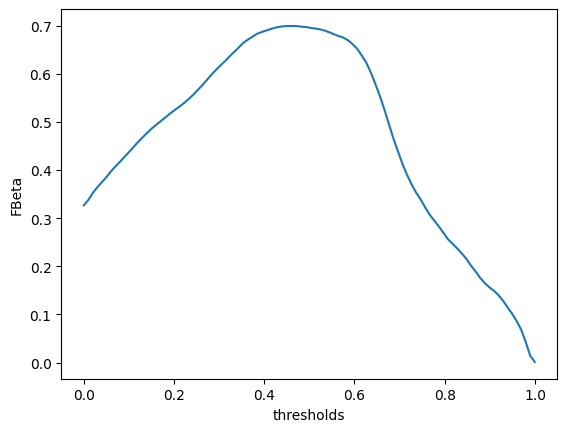

In [91]:
sns.lineplot(
    data= threshold_resultd,
    x = "thresholds",
    y = "scores"
)
plt.ylabel("FBeta")
plt.show()

In [92]:
pipe_best = threshold_optimized_model
pipe_best

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                                        'deposit_type',
                                                                                        'customer_type']),
                                                                                      ('binary',
                                                                                       BinaryEncoder(),
                                                                                       ['meal',
                                                                                        'distribution_channel',
                                                                                        'market_segment',
                                                                                        'reserved_room_type',
                                                                                        'arrival_date_month',
                                                                                        'country'])])),
                                                     ('model',
                                                      RandomForestClassifier(max_depth=14,
                                                                             min_samples_split=4,
                                                                             n_estimators=250,
                                                                             random_state=0))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

- ### **xgboost hyperparameter**

In [93]:
pipe_basexgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [94]:
# param_spacexgb = {
#     "model__n_estimators": range(100, 500, 50),
#     "model__max_depth": range(5, 15),
#     "model__min_child_weight": range(5, 15),
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2]
# }

In [95]:

param_spacexgb = {
    # Regularisasi untuk cegah overfitting
    "model__max_depth"        : [3, 4, 5, 6],       # Kedalaman maksimum setiap pohon
    "model__min_child_weight" : [3, 5, 7, 10],      # Minimum jumlah data di setiap leaf node
    "model__gamma"            : [0.1, 0.3, 0.5],    # Minimum PENURUNAN LOSS yang diperlukan untuk melakukan split pada leaf
    "model__subsample"        : [0.6, 0.7, 0.8],    # Proporsi data training yang digunakan untuk membangun setiap pohon
    "model__colsample_bytree" : [0.6, 0.7, 0.8],    # PROPORSI FITUR (kolom) yang digunakan secara ACAK 
    "model__reg_alpha"        : [0.1, 0.5, 1.0],    # L1 (ridge)
    "model__reg_lambda"       : [1.0, 2.0, 5.0],    # L2 (lasso)
    "model__learning_rate"    : [0.01, 0.05, 0.1],  # Mengatur SEBERAPA BESAR kontribusi setiap pohon baru terhadap prediksi akhir
    "model__n_estimators"     : [100, 200, 300],    # Jumlah pohon
    "model__scale_pos_weight" : [1, 2, 3]           # handle imbalance, mengatur bobot kelas positif
}

In [96]:
fbeta = make_scorer(fbeta_score, beta= 0.5)

randomsearchxgb = RandomizedSearchCV(
    random_state = 0,
    estimator = pipe_basexgb,
    param_distributions = param_spacexgb,
    cv = 3,
    scoring = fbeta,
    n_iter = 50,
    n_jobs = -1
)

randomsearchxgb

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_wai...
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [3, 5, 7,
                                                                    10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__reg_alpha': [0.1, 0.5, 1.0],
                                        'model__reg_lambda': [1.0, 2.0, 5.0],
                                        'model__scale_pos_weight': [1, 2, 3],
                                        'model__subsample': [0.6, 0.7, 0.8]},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [97]:
randomsearchxgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_wai...
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [3, 5, 7,
                                                                    10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__reg_alpha': [0.1, 0.5, 1.0],
                                        'model__reg_lambda': [1.0, 2.0, 5.0],
                                        'model__scale_pos_weight': [1, 2, 3],
                                        'model__subsample': [0.6, 0.7, 0.8]},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [98]:
randomsearchxgb.best_score_ # Skor validasi silang presisi dari penyetelan

0.7110257834838155

In [99]:
randomsearchxgb.best_params_

{'model__subsample': 0.6,
 'model__scale_pos_weight': 1,
 'model__reg_lambda': 5.0,
 'model__reg_alpha': 0.5,
 'model__n_estimators': 300,
 'model__min_child_weight': 3,
 'model__max_depth': 6,
 'model__learning_rate': 0.1,
 'model__gamma': 0.1,
 'model__colsample_bytree': 0.7}

In [100]:
# Get best model
pipe_tunedxgb = randomsearchxgb.best_estimator_
pipe_tunedxgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
                               feature_types=None, gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=0, ...))])

- Threshold optimization

In [101]:
# cari threshold terbaik untuk model yg sudah dituning 

fbeta = make_scorer(fbeta_score, beta= 0.5)

threshold_optimized_modelxgb = TunedThresholdClassifierCV(
    estimator= pipe_tunedxgb,
    scoring= fbeta,
    cv =5,
    store_cv_results= True
)

threshold_optimized_modelxgb.fit(X_train, y_train)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [102]:
threshold_resultdxgb = pd.DataFrame(
    threshold_optimized_model.cv_results_
)

threshold_resultdxgb

,thresholds,scores
0,0.000000,0.326655
1,0.010096,0.337685
2,0.020192,0.352636
3,0.030289,0.364464
4,0.040385,0.375117
...,...,...
95,0.959136,0.086700
96,0.969232,0.068893
97,0.979328,0.043505
98,0.989425,0.014443


In [103]:
threshold_optimized_modelxgb.best_threshold_

0.5454257641249569

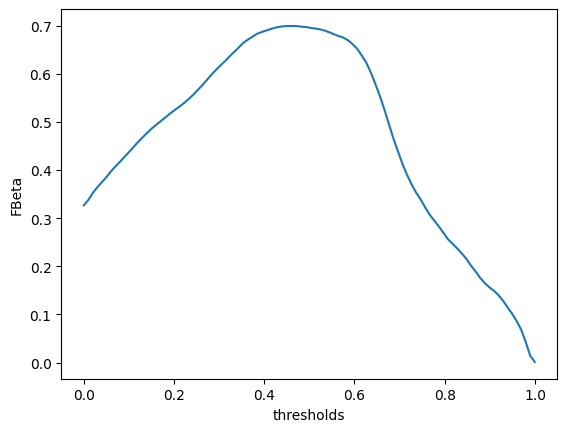

In [104]:
sns.lineplot(
    data= threshold_resultdxgb,
    x = "thresholds",
    y = "scores"
)
plt.ylabel("FBeta")
plt.show()

In [105]:
pipe_bestxgb = threshold_optimized_modelxgb
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

## **9. Best Model Evaluation**

### **random forest**

In [106]:
pipe_base.fit(X_train, y_train)

y_train_base = pipe_base.predict(X_train)
y_test_base = pipe_base.predict(X_test)

fbeta_train_base = fbeta_score(y_train, y_train_base, beta= 0.5)
fbeta_test_base = fbeta_score(y_test, y_test_base, beta= 0.5)

print("BASE MODEL")
print(f"fbeta Train = {fbeta_train_base:.2%}")
print(f"fbeta Test = {fbeta_test_base:.2%}")

BASE MODEL
fbeta Train = 99.22%
fbeta Test = 71.16%


In [107]:
pipe_best.fit(X_train, y_train)

y_train_best = pipe_best.predict(X_train)
y_test_best = pipe_best.predict(X_test)

fbeta_train_best = fbeta_score(y_train, y_train_best, beta= 0.5)
fbeta_test_best = fbeta_score(y_test, y_test_best, beta= 0.5)

print("best MODEL")
print(f"fbeta Train = {fbeta_train_best:.2%}")
print(f"fbeta Test = {fbeta_test_best:.2%}")

best MODEL
fbeta Train = 73.49%
fbeta Test = 68.85%


### **xgboost**

In [108]:
pipe_basexgb.fit(X_train, y_train)

y_train_basexgb = pipe_basexgb.predict(X_train)
y_test_basexgb = pipe_basexgb.predict(X_test)

fbeta_train_basexgb = fbeta_score(y_train, y_train_basexgb, beta= 0.5)
fbeta_test_basexgb = fbeta_score(y_test, y_test_basexgb, beta= 0.5)

print("basexgb MODEL")
print(f"fbeta Train = {fbeta_train_basexgb:.2%}")
print(f"fbeta Test = {fbeta_test_basexgb:.2%}")

basexgb MODEL
fbeta Train = 67.34%
fbeta Test = 62.86%


**Hasil:**
- Precision  = 3924/(3924+2689)  = 59.34%  
- Recall     = 3924/(3924+837)   = 82.43%  
- F-Beta Train = 67.34%          
- F-Beta Test  = 62.86%          
- Gap          = 4.48%    ---> Tidak Overfit
- Accuracy   = (9579+3924)/17029 = 79.29%  

In [109]:
pipe_bestxgb.fit(X_train, y_train)

y_train_bestxgb = pipe_bestxgb.predict(X_train)
y_test_bestxgb = pipe_bestxgb.predict(X_test)

fbeta_train_bestxgb = fbeta_score(y_train, y_train_bestxgb, beta= 0.5)
fbeta_test_bestxgb = fbeta_score(y_test, y_test_bestxgb, beta= 0.5)

print("bestxgb MODEL")
print(f"fbeta Train = {fbeta_train_bestxgb:.2%}")
print(f"fbeta Test = {fbeta_test_bestxgb:.2%}")

bestxgb MODEL
fbeta Train = 75.62%
fbeta Test = 70.87%


**Hasil:**

- Precision  = 2750/(2750+910)   = 75.14%  
- Recall     = 2750/(2750+2011)  = 57.76%  
- F-Beta Train = 75.62%          
- F-Beta Test  = 70.87%          
- Gap          = 4.75% ---> tidak overviting      
- Accuracy   = (11358+2750)/17029= 82.85%  

### **9.1 Cost Evaluation**

In [110]:
# Set cost

FN_COST = 105
FP_COST = 300
TP_BENEFIT = 0

In [111]:
# Define cost-benefit function
def summarize_loss(confusion_matrix, fp_cost, fn_cost, tp_benefit):
    tn, fp = confusion_matrix[0]
    fn, tp = confusion_matrix[1]
    
    total_samples = tn + fp + fn + tp
    total_fp_cost = fp * -1 * fp_cost
    total_fn_cost = fn * -1 * fn_cost
    total_tp_benefit = tp * tp_benefit
    
    total_benefit = total_fp_cost + total_fn_cost + total_tp_benefit
    
    summary = f"""
    ---Impact Summary---

        Total Sampel: {total_samples}
        Total False Positive Cost: {total_fp_cost:,.2f} euro
        Total False Negative Cost: {total_fn_cost:,.2f} euro
        Total True Positive Benefit: {total_tp_benefit:,.2f} euro
        Total Benefit: {total_benefit:,.2f} euro
        Total Benefit per Sample: {total_benefit / total_samples} euro
        
    ---------------
    """
    
    return summary

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### **random forest**

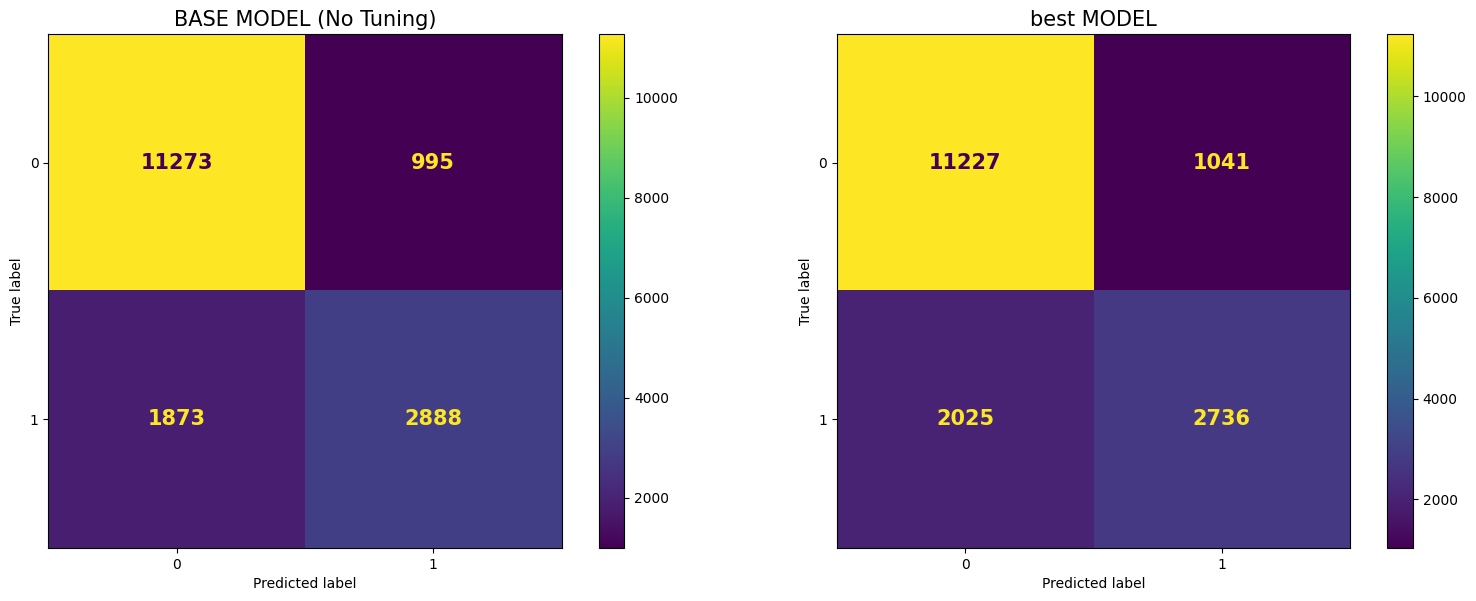

In [113]:
# Calculate confusion matrices for base model and best model
conf_matrix_base = confusion_matrix(y_test, y_test_base)

conf_matrix_best = confusion_matrix(y_test, y_test_best)

# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))

text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_base).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("BASE MODEL (No Tuning)", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_best).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("best MODEL", fontsize=15)

plt.tight_layout()
plt.show()

**Kesimpulan:**

- Berdasarkan hasil modeling yang telah dilakukan didapatkan bahwa cost/ kerugian perusahaan sebesar:

1. Sebelum Tuning
- FP = 995 
- FN = 1873


2. Setelah Tuning
- FP = 1076
- FN = 2070


In [114]:
# Compare business impact
print("=" * 100)
print("BASE MODEL (NO TUNING)")
print("=" * 100)
print(summarize_loss(conf_matrix_base, FP_COST, FN_COST, TP_BENEFIT))

print("=" * 100)
print("BEST MODEL")
print("=" * 100)
print(summarize_loss(conf_matrix_best, FP_COST, FN_COST, TP_BENEFIT))

BASE MODEL (NO TUNING)

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -298,500.00 euro
        Total False Negative Cost: -196,665.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -495,165.00 euro
        Total Benefit per Sample: -29.077749721064066 euro

    ---------------
    
BEST MODEL

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -312,300.00 euro
        Total False Negative Cost: -212,625.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -524,925.00 euro
        Total Benefit per Sample: -30.82535674437724 euro

    ---------------
    


BASE MODEL:
- FP Cost = -298,500 ---> prediksi "batal" tapi tidak batal
- FN Cost = -196,665  ----> pembatalan tidak terdekteksi
- total = **-495,165**

BEST MODEL:
- FP Cost = -322,800 
- FN Cost = -217,350 
- total = **-540,150**

In [115]:
# Benchmark: Tanpa model (memprediksi semuanya tidak ada pembatalan)
print("=" * 100)
print("MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa tidak semua pelanggan akan membatalkan pesanan.")
print("=" * 100)
y_no_model = np.zeros(y_test.shape[0])
conf_matrix_no_model = confusion_matrix(y_test, y_no_model)
print(summarize_loss(conf_matrix_no_model, 
                     fp_cost=FP_COST, 
                     fn_cost=FN_COST, 
                     tp_benefit=TP_BENEFIT))

MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa tidak semua pelanggan akan membatalkan pesanan.

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: 0.00 euro
        Total False Negative Cost: -499,905.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -499,905.00 euro
        Total Benefit per Sample: -29.35609842034177 euro

    ---------------
    


In [116]:
# Benchmark: No model (predict all will not cancel)
print("=" * 100)
print("TIDAK ADA MODEL PESIMISTIS: Memprediksi semua pelanggan akan membatalkan pesanan")
print("=" * 100)
y_no_model = np.ones(y_test.shape[0])
conf_matrix_no_model = confusion_matrix(y_test, y_no_model)
print(summarize_loss(conf_matrix_no_model, 
                     fp_cost=FP_COST, 
                     fn_cost=FN_COST, 
                     tp_benefit=TP_BENEFIT))

TIDAK ADA MODEL PESIMISTIS: Memprediksi semua pelanggan akan membatalkan pesanan

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -3,680,400.00 euro
        Total False Negative Cost: 0.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -3,680,400.00 euro
        Total Benefit per Sample: -216.1254330847378 euro

    ---------------
    


### **xgboost**

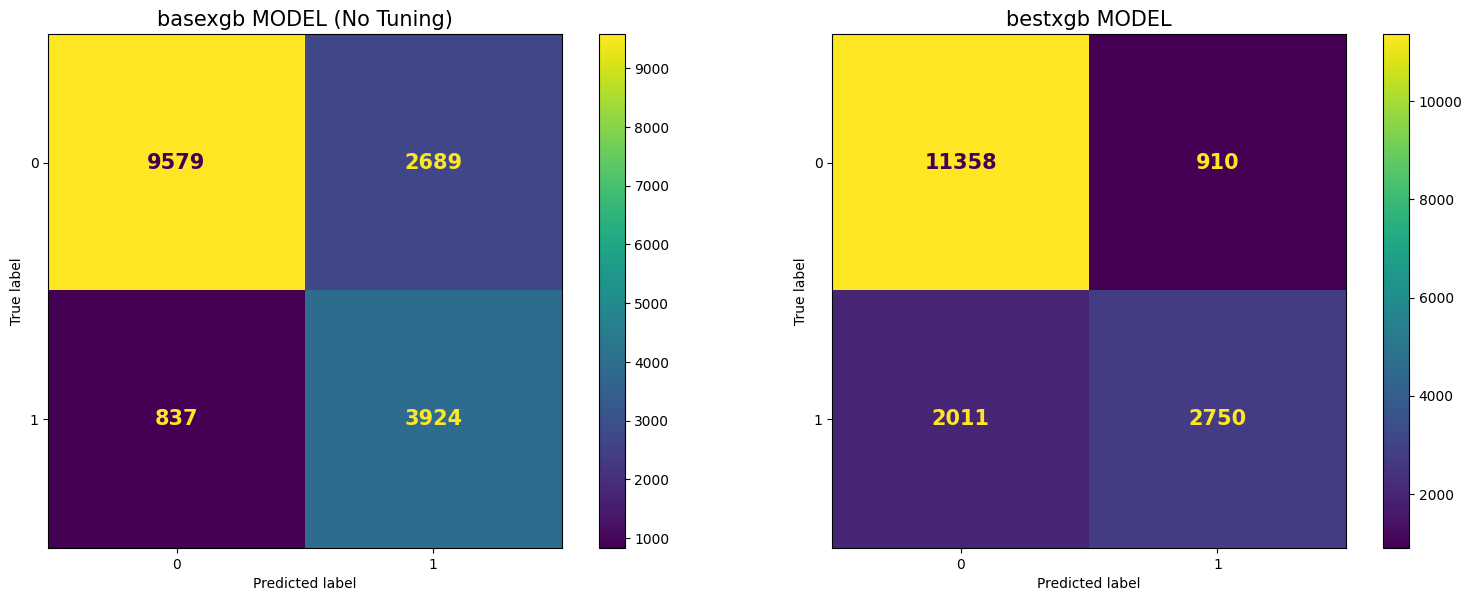

In [117]:
# Calculate confusion matrices for basexgb model and bestxgbxgbmodel
conf_matrix_basexgb = confusion_matrix(y_test, y_test_basexgb)

conf_matrix_bestxgb = confusion_matrix(y_test, y_test_bestxgb)

# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))

text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_basexgb).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("basexgb MODEL (No Tuning)", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_bestxgb).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("bestxgb MODEL", fontsize=15)

plt.tight_layout()
plt.show()

**Kesimpulan:**

1. Sebelum Tuning
- FP = 2689
- FN = 837

2. Setelah Tuning
- FP = 910
- FN = 2011

Dari **17,029** total pemesanan hotel:

**11,358** --> benar prediksi "Tidak batal" `TN`
- (tamu tetep menginap, tidak perlu mengeluarkan biaya kompensasi dll)

**2,750** --> benar prediksi "Batal" `TP`
- sebanyak 57,76% pembatalan terdekteksi 
- (hotel bisa antisipasi, siapkan strategi)

**910** --> salah prediksi "Batal `FP`
- (tamu tidak jadi batal, hotel harus mengeluarkan kompensasi untuk pengunjung)
- kerugian 273,000 euro (sia-sia)
- per kasus = 300 euro

**2,011** --> salah prediksi "tidak batal" `FN`
- (pembatalan tidak terdekteksi, hotel kaget kamar kosong banyak)
- keruguan 211,155 euro
- per kasus = 105 euro

In [118]:
# Compare business impact
print("=" * 100)
print("BASE MODEL (NO TUNING)")
print("=" * 100)
print(summarize_loss(conf_matrix_basexgb, FP_COST, FN_COST, TP_BENEFIT))

print("=" * 100)
print("BEST MODEL")
print("=" * 100)
print(summarize_loss(conf_matrix_bestxgb, FP_COST, FN_COST, TP_BENEFIT))

BASE MODEL (NO TUNING)

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -806,700.00 euro
        Total False Negative Cost: -87,885.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -894,585.00 euro
        Total Benefit per Sample: -52.53303188678137 euro

    ---------------
    
BEST MODEL

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -273,000.00 euro
        Total False Negative Cost: -211,155.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -484,155.00 euro
        Total Benefit per Sample: -28.43120559046333 euro

    ---------------
    


Berdasarkan hasil modeling yang telah dilakukan didapatkan bahwa cost/ kerugian perusahaan sebesar:

**BASE MODEL:**
- FP Cost = -806,700 ---> prediksi "batal" tapi tidak batal
- FN Cost = -87,885  ----> pembatalan tidak terdekteksi
- total = **-894,585 euro**

**BEST MODEL:**
- FP Cost = -273,000
- FN Cost = -211,155
- total = **-484,155 euro**


**Best model dibandingkan tanpa model (semua diprediksi tidak batal):**

FN = 4,761 x 105 euro = -499,905 euro

499,905 - 484,155 = 15,750 euro lebih hemat 

**Best model dibandingkan Base model:**

894,585 - 484,155 = 410,430 euro lebih hemat

In [119]:
# Benchmark: Tanpa model (memprediksi semuanya tamu tidak akan membatalkan)
print("=" * 100)
print("MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa tidak semua pelanggan akan membatalkan pesanan.")
print("=" * 100)
y_no_modelxgb = np.zeros(y_test.shape[0])
conf_matrix_no_modelxgb = confusion_matrix(y_test, y_no_modelxgb)
print(summarize_loss(conf_matrix_no_modelxgb, 
                     fp_cost=FP_COST, 
                     fn_cost=FN_COST, 
                     tp_benefit=TP_BENEFIT))

MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa tidak semua pelanggan akan membatalkan pesanan.

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: 0.00 euro
        Total False Negative Cost: -499,905.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -499,905.00 euro
        Total Benefit per Sample: -29.35609842034177 euro

    ---------------
    


**Prediksi semua = 0 (tidak batal):**

- TN = 12,268  → Benar prediksi tidak batal
- FP = 0       → Tidak ada yang diprediksi batal
- FN = 4,761   → SEMUA pembatalan terlewatkan
- TP = 0       → Tidak ada pembatalan terdeteksi

Total Cost: 4,761 x -105 euro = **-499,905 euro**

In [120]:
# Benchmark: No model (Prediksi semua tamu AKAN membatalkan)
print("=" * 100)
print("TIDAK ADA MODEL PESIMISTIS: Memprediksi semua pelanggan akan membatalkan pesanan")
print("=" * 100)
y_no_modelxgb = np.ones(y_test.shape[0])
conf_matrix_no_modelxgb = confusion_matrix(y_test, y_no_modelxgb)
print(summarize_loss(conf_matrix_no_modelxgb, 
                     fp_cost=FP_COST, 
                     fn_cost=FN_COST, 
                     tp_benefit=TP_BENEFIT))

TIDAK ADA MODEL PESIMISTIS: Memprediksi semua pelanggan akan membatalkan pesanan

    ---Impact Summary---

        Total Sampel: 17029
        Total False Positive Cost: -3,680,400.00 euro
        Total False Negative Cost: 0.00 euro
        Total True Positive Benefit: 0.00 euro
        Total Benefit: -3,680,400.00 euro
        Total Benefit per Sample: -216.1254330847378 euro

    ---------------
    


**Prediksi semua = 1 (batal):**

- TN = 0       → Tidak ada yang diprediksi tidak batal
- FP = 12,268  → SEMUA tidak-batal salah diprediksi batal
- FN = 0       → Tidak ada pembatalan terlewat
- TP = 4,761   → Semua pembatalan terdeteksi

Total Cost = 2,268 × 300 = **-3,680,400 euro**

## **10. Train Best Model with All Data**

In [121]:
pipe_bestxgb.fit(X, y)
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

## **11. Save Best Model**

In [122]:
import pickle

In [123]:
filename = "best_model_hotel_demand_030526_1109.pkl"

with open(filename, "wb") as f:
    pickle.dump(pipe_bestxgb, f)

print(f"Successfully saved best model as {filename}")

Successfully saved best model as best_model_hotel_demand_030526_1109.pkl


## **12. Model Explanation**

### **12.1 Cara Kerja XGBoost**

- XGBoost (Extreme Gradient Boosting) adalah metode pembelajaran ensemble berbasis boosting yang membangun pohon keputusan secara berurutan, di mana setiap pohon baru berfokus untuk memperbaiki kesalahan dari pohon sebelumnya

- Berbeda dengan Random Forest yang membangun pohon secara paralel dan independen, XGBoost membangun pohon secara sekuensial di mana setiap pohon baru dilatih untuk meminimalkan sisa kesalahan (residual error) dari model sebelumnya menggunakan teknik Gradient Descent

- Pada setiap iterasi, XGBoost menghitung gradien (arah kesalahan) dan hessian (kelengkungan kesalahan) dari fungsi loss untuk menentukan bagaimana pohon berikutnya harus dibangun agar prediksi semakin mendekati nilai sebenarnya

- XGBoost menggunakan teknik regularisasi L1 (reg_alpha) dan L2 (reg_lambda) yang secara langsung dikodekan ke dalam fungsi objektif untuk mengontrol kompleksitas model, sehingga mengurangi risiko overfitting yang sering terjadi pada metode boosting tradisional

- Parameter seperti learning rate mengontrol seberapa besar kontribusi setiap pohon baru terhadap prediksi akhir, di mana learning rate kecil menghasilkan model yang lebih general namun membutuhkan lebih banyak pohon (n_estimators), sementara subsample dan colsample_bytree memperkenalkan keacakan seperti Random Forest untuk meningkatkan keberagaman pohon

- Prediksi akhir XGBoost merupakan penjumlahan kumulatif dari seluruh pohon yang dibangun, di mana setiap pohon memberikan kontribusi sebesar hasil prediksinya dikalikan dengan learning rate, sehingga secara bertahap mendekati nilai target yang sesungguhnya

- Pada kasus data tidak seimbang seperti prediksi pembatalan hotel, XGBoost menyediakan parameter scale_pos_weight sebagai pengganti resampling yang memberikan bobot lebih besar pada kelas minoritas (pembatalan) sehingga model lebih sensitif dalam mendeteksi pembatalan tanpa harus mengubah distribusi data asl

### **12.2 Model Explanation with SHAP**

In [124]:
import shap

c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [125]:
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [126]:
pipe_bestxgb_inner = pipe_bestxgb.estimator
pipe_bestxgb_inner

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_par...
                               feature_types=None, gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=0, ...))])

In [127]:
xgb_best = pipe_bestxgb_inner[-1]
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [128]:
xgb_preprocess = pipe_bestxgb_inner[-2]
xgb_preprocess

ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'is_by_agent', 'is_by_company'],
      dtype='object')),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['hotel', 'deposit_type', 'customer_type']),
                                ('binary', BinaryEncoder(),
                                 ['meal', 'distribution_channel',
                                  'market_segment', 'reserved_room_type',
                                  'arrival_date_month', 'country'])])

In [129]:
X_transform = xgb_preprocess.transform(X)
X_transform

,robust__lead_time,robust__arrival_date_year,robust__stays_in_weekend_nights,robust__stays_in_week_nights,robust__adults,robust__children,robust__babies,robust__previous_cancellations,robust__previous_bookings_not_canceled,robust__booking_changes,robust__days_in_waiting_list,robust__adr,robust__required_car_parking_spaces,robust__total_of_special_requests,robust__is_by_agent,robust__is_by_company,onehot__hotel_Resort Hotel,onehot__deposit_type_Non Refund,onehot__deposit_type_Refundable,onehot__customer_type_Group,onehot__customer_type_Transient,onehot__customer_type_Transient-Party,binary__meal_0,binary__meal_1,binary__meal_2,binary__distribution_channel_0,binary__distribution_channel_1,binary__distribution_channel_2,binary__market_segment_0,binary__market_segment_1,binary__market_segment_2,binary__reserved_room_type_0,binary__reserved_room_type_1,binary__reserved_room_type_2,binary__reserved_room_type_3,binary__arrival_date_month_0,binary__arrival_date_month_1,binary__arrival_date_month_2,binary__arrival_date_month_3,binary__country_0,binary__country_1,binary__country_2,binary__country_3,binary__country_4,binary__country_5,binary__country_6,binary__country_7
2,-0.382609,-1.0,-0.5,-0.333333,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.398671,0.0,-1.0,-1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,1,0,0,1,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1
3,-0.330435,-1.0,-0.5,-0.333333,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.398671,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,1,1,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1
4,-0.321739,-1.0,-0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.016611,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1
5,-0.443478,-1.0,-0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.132890,0.0,-1.0,-1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,1,0,0,1,1,0,1,1,1,0,1,1,1,0,0,0,0,0,0,1,1
6,-0.365217,-1.0,-0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.066445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,0,1,0,1,0,0,1,1,0,1,1,1,0,1,1,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86935,-0.243478,1.0,0.5,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.047508,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1,1,0,1,0
86936,0.443478,1.0,0.5,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100166,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,0,1
86937,-0.147826,1.0,0.5,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.975249,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0
86938,0.504348,1.0,0.5,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.089701,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1


In [130]:
# define explainer SHAP
explainer_shap = shap.TreeExplainer(
    model = xgb_best
)

shap_values = explainer_shap.shap_values(X_transform)

In [131]:
feature_names = xgb_preprocess.get_feature_names_out()
feature_names

array(['robust__lead_time', 'robust__arrival_date_year',
       'robust__stays_in_weekend_nights', 'robust__stays_in_week_nights',
       'robust__adults', 'robust__children', 'robust__babies',
       'robust__previous_cancellations',
       'robust__previous_bookings_not_canceled',
       'robust__booking_changes', 'robust__days_in_waiting_list',
       'robust__adr', 'robust__required_car_parking_spaces',
       'robust__total_of_special_requests', 'robust__is_by_agent',
       'robust__is_by_company', 'onehot__hotel_Resort Hotel',
       'onehot__deposit_type_Non Refund',
       'onehot__deposit_type_Refundable', 'onehot__customer_type_Group',
       'onehot__customer_type_Transient',
       'onehot__customer_type_Transient-Party', 'binary__meal_0',
       'binary__meal_1', 'binary__meal_2',
       'binary__distribution_channel_0', 'binary__distribution_channel_1',
       'binary__distribution_channel_2', 'binary__market_segment_0',
       'binary__market_segment_1', 'binary__market

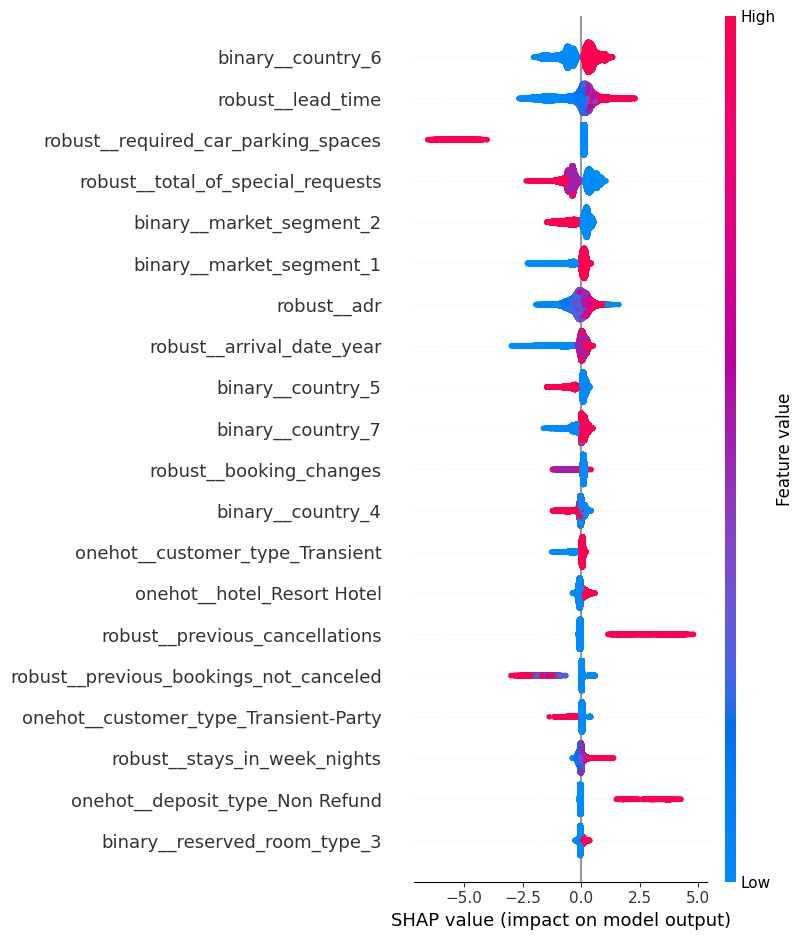

In [132]:
# Tampilkan model explanation dalam shap plot
shap.summary_plot(
    shap_values,
    X_transform,
    feature_names
)

Keterangan:
- Sumbu X  = SHAP Value (dampak terhadap prediksi)
- Kanan(+) = Mendorong prediksi BATAL
- Kiri (-) = Mendorong prediksi TIDAK BATAL
- Merah    = Nilai fitur TINGGI
- Biru     = Nilai fitur RENDAH

- `country_6`; Tamu yang berasal dari negara tertentu (nilai merah/tinggi) mendorong prediksi ke arah pembatalan secara signifikan. Hal ini menunjukkan bahwa asal negara tamu merupakan faktor paling dominan dalam menentukan risiko pembatalan, kemungkinan mencerminkan perbedaan budaya pemesanan, kebijakan visa, jarak perjalanan, serta kebiasaan perencanaan liburan antar negara yang berbeda-beda, sehingga tamu dari negara tertentu secara konsisten menunjukkan pola pembatalan yang lebih tinggi dibandingkan negara lainnya.

- `lead_time`; Tamu yang memesan jauh hari sebelum tanggal kedatangan (nilai merah/tinggi) mendorong prediksi ke arah pembatalan secara kuat. Hal ini menunjukkan bahwa semakin panjang jarak waktu antara tanggal pemesanan dan tanggal kedatangan, semakin tinggi ketidakpastian rencana perjalanan tamu, sementara tamu yang memesan mendekati tanggal kedatangan cenderung memiliki komitmen yang lebih kuat dan jarang membatalkan pemesanan mereka.

- `required_car_parking_spaces`; Tamu yang memesan tempat parkir kendaraan (nilai merah/tinggi) justru mendorong prediksi menjauh dari pembatalan. Hal ini mengindikasikan bahwa tamu yang meminta fasilitas parkir memiliki tingkat komitmen dan keseriusan yang lebih tinggi terhadap rencana menginap mereka, karena mereka telah merencanakan perjalanan secara lebih detail termasuk transportasi pribadi, sehingga menjadi indikator loyalitas tamu yang kuat.

- `total_of_special_requests`; Tamu dengan jumlah permintaan khusus yang sedikit (nilai biru/rendah) cenderung mendorong prediksi menjauh dari pembatalan, sementara tamu dengan banyak permintaan khusus (nilai merah/tinggi) sedikit mendorong ke arah pembatalan. Hal ini menunjukkan bahwa tamu yang memiliki banyak ekspektasi spesifik terhadap layanan hotel lebih rentan membatalkan pemesanan apabila permintaan mereka tidak dapat dipenuhi atau terdapat ketidaksesuaian antara harapan dan kondisi aktual hotel.

- `market_segment`; Segmen pasar tertentu (ditangkap melalui pengkodean biner) mendorong prediksi ke arah pembatalan secara berbeda-beda. Hal ini menunjukkan bahwa saluran pemesanan memainkan peran penting dalam perilaku pembatalan tamu, di mana segmen Online Travel Agent (OTA) cenderung memiliki tingkat pembatalan lebih tinggi karena kemudahan proses pembatalan dan kebijakan refund yang fleksibel, sementara tamu yang memesan secara langsung (direct booking) menunjukkan komitmen yang lebih kuat terhadap pemesanan mereka.

- `adr (Average Daily Rate)`; Tamu yang memesan kamar dengan harga per malam yang tinggi (nilai merah/tinggi) mendorong prediksi ke arah pembatalan. Hal ini menunjukkan bahwa tamu yang membayar tarif kamar lebih mahal cenderung lebih sensitif terhadap perubahan harga dan kondisi, lebih sering membandingkan pilihan akomodasi lain, serta lebih berani membatalkan pemesanan apabila menemukan penawaran yang lebih baik atau terjadi perubahan rencana perjalanan.

- `deposit_type_Non Refund`; Tamu yang memilih tipe deposit Non-Refund (nilai merah/tinggi) mendorong prediksi menjauh dari pembatalan secara signifikan. Hal ini membuktikan bahwa kebijakan deposit Non-Refund sangat efektif dalam mencegah pembatalan, karena tamu yang telah membayar deposit yang tidak dapat dikembalikan memiliki konsekuensi finansial yang jelas apabila membatalkan pemesanan, sehingga mendorong mereka untuk tetap melanjutkan rencana menginap.

- `previous_cancellations`; Tamu yang memiliki riwayat pembatalan sebelumnya yang tinggi (nilai merah/tinggi) mendorong prediksi ke arah pembatalan dengan kuat. Hal ini menegaskan bahwa histori perilaku pembatalan merupakan prediktor yang sangat kuat, di mana tamu yang pernah membatalkan pemesanan di masa lalu memiliki kecenderungan yang jauh lebih tinggi untuk kembali membatalkan pemesanan berikutnya, sehingga riwayat tamu perlu menjadi pertimbangan utama dalam strategi manajemen risiko pembatalan hotel.

## **13. Kesimpulan**

- Model XGBoost best dapat mengidentifikasi tamu hotel yang kemungkinan besar akan membatalkan pemesanan mereka dengan **akurasi 75.14%**, artinya dari setiap 100 tamu yang diprediksi akan membatalkan, sekitar 75 tamu benar-benar akan membatalkan pemesanan, sehingga hotel dapat melakukan intervensi yang lebih tepat sasaran dan efisien.

- Penggunaan model ini mengurangi total kerugian bisnis menjadi **-484,155 euro per 17.029 pemesanan** atau setara **-28,43 euro per pemesanan**, menghemat **15,75 euro** dibandingkan dengan tidak menggunakan model sama sekali dan **410,430 euro** dibandingkan dengan model tanpa tuning (Base Model).

- Tanpa model hotel menghadapi dua skenario yang merugikan yaitu, kerugian sebesar **-499,905 euro** akibat seluruh pembatalan tidak terdekteksi (model tidak optimis, memprediksi semua tamu tidak batal) atau **-3,680,400** akibat biaya intervensi yang dilakukan kepada seluruh tamu tanpa seleksi (Model Pesimistis, memprediksi semua tamu batal); keduanya jauh lebih buruk dibandingkan hasil model XGBoost best.

- Model ini mencapai keseimbangan yang efektif antara dua jenis kesalahan prediksi, yaitu menjaga biaya intervensi sia-sia akibat prediksi batal yang salah **(False Positive) tetap rendah di -273,000 euro** untuk 910 kasus, sambil menerima tingkat pembatalan yang terlewatkan **(False Negative) yang dapat dikelola di -211,155 euro** untuk 2.011 kasus, selaras dengan prioritas bisnis yang menggunakan scoring **F-Beta (β=0.5)** untuk lebih menekankan presisi dibandingkan recall guna menghindari pemborosan biaya intervensi yang tidak perlu.

- Model XGBoost terbaik yang dilatih dengan seluruh data menunjukkan generalisasi yang sangat baik dengan **F-Beta score sebesar 70,87%** dan gap antara data latih dan data uji hanya sebesar **4,75%**, membuktikan bahwa model tidak mengalami overfitting dan dapat diandalkan untuk memprediksi pembatalan pemesanan hotel pada data baru di masa mendatang.

## **14. Recommendations**

- **Terapkan model dalam sistem manajemen pemesanan hotel** untuk menandai tamu berisiko tinggi pembatalan pada saat pemesanan dilakukan, memungkinkan tim revenue management untuk secara selektif melakukan tindakan intervensi hanya kepada tamu yang diprediksi akan membatalkan, dengan target penghematan **15,750 euro per 17.029 pemesanan** dibandingkan tidak menggunakan model sama sekali, dan **410,430 euro** dibandingkan model tanpa tuning.

- **Rancang strategi retensi yang ditargetkan berdasarkan fitur-fitur penting dari SHAP plot**, seperti memberikan penawaran khusus atau konfirmasi ulang kepada tamu dengan **lead time panjang**, tamu dari **negara dengan cancel rate tinggi**, serta tamu dengan **ADR tinggi** yang diidentifikasi sebagai kelompok berisiko tinggi, dengan tujuan mengkonversi sebagian dari **2.011 kasus False Negative** menjadi pemesanan yang berhasil dipertahankan.

- **Tetapkan ambang batas pemantauan pada F-Beta score dan presisi model**: jika F-Beta score produksi turun di bawah 65% atau presisi turun di bawah 70%, segera lakukan pelatihan ulang model karena penurunan presisi dari 75% ke 70% akan meningkatkan jumlah False Positive dan biaya intervensi sia-sia yang saat ini sudah mencapai **273,000 euro**, sehingga berdampak langsung pada total kerugian bisnis yang melampaui angka **484,155 euro**.

- **Prioritaskan penanganan segmen pasar berisiko tinggi** yang diidentifikasi oleh SHAP plot seperti segmen **Online Travel Agent (OTA)** dan tamu dengan **histori pembatalan sebelumnya**, dengan menerapkan kebijakan pemesanan yang lebih ketat seperti deposit wajib atau batas waktu konfirmasi lebih awal, untuk menekan angka **2.011 pembatalan yang tidak terdeteksi** dan mengurangi kerugian FN sebesar **211,155 euro**

- **Integrasikan model dengan sistem Early Warning Dashboard** yang menampilkan daftar tamu berisiko tinggi secara real-time kepada tim operasional hotel setiap harinya, sehingga manajemen dapat mengambil tindakan proaktif seperti menghubungi tamu, menawarkan upgrade kamar, atau menyiapkan strategi overbooking yang terukur untuk meminimalkan dampak finansial dari pembatalan yang tidak terduga

## **15.Deployment Preparation**

In [133]:
# Save representasi model detail sebagai string
detailed_model_dict = pipe_bestxgb.get_params()
detailed_model_dict = str(detailed_model_dict)
print(detailed_model_dict)

{'cv': 5, 'estimator__memory': None, 'estimator__steps': [('preprocess', ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'is_by_agent', 'is_by_company'],
      dtype='object')),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['hotel', 'deposit_type', 'customer_type']),
                                ('binary', BinaryEncoder(),
                       

In [134]:
pipe_string_detail_filename = "pipe_bestxgb_detail_030526.txt"

with open(pipe_string_detail_filename, "w") as f:
    f.write(detailed_model_dict)

print(f"Berhasil menyimpan pada {pipe_string_detail_filename}")

Berhasil menyimpan pada pipe_bestxgb_detail_030526.txt


In [135]:
# Representasi model sebagai string (overview)
pipe_bestxgb_as_string = str(pipe_bestxgb)
print(pipe_bestxgb_as_string)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'day...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                      

In [136]:
pipe_string_filename = "pipe_bestxgb_030526.txt"

with open(pipe_string_filename, "w") as f:
    f.write(pipe_bestxgb_as_string)

print(f"Berhasil menyimpan pada {pipe_string_filename}")

Berhasil menyimpan pada pipe_bestxgb_030526.txt


In [137]:
feature_head_example = X.head()
feature_head_example.to_csv("feature_head_example.csv", index=False)

In [138]:
categorical_feature_cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type',
       'customer_type'],
      dtype='object')

In [139]:
list_unique_categories = [] # akan di append list dari tiap fitur

for category in categorical_feature_cols:
    categories = X[category].unique()
    list_unique_categories.append(categories)

In [140]:
df_categories = pd.DataFrame()
df_categories["feature_name"] = categorical_feature_cols
df_categories["categories"] = list_unique_categories
df_categories

,feature_name,categories
0,hotel,"[Resort Hotel, City Hotel]"
1,arrival_date_month,"[July, August, September, October, November, D..."
2,meal,"[BB, FB, HB, SC, Undefined]"
3,country,"[GBR, PRT, USA, ESP, IRL, FRA, ROU, NOR, OMN, ..."
4,market_segment,"[Direct, Corporate, Online TA, Offline TA/TO, ..."
5,distribution_channel,"[Direct, Corporate, TA/TO, Undefined, GDS]"
6,reserved_room_type,"[A, C, D, E, G, F, H, L, B]"
7,deposit_type,"[No Deposit, Refundable, Non Refund]"
8,customer_type,"[Transient, Contract, Transient-Party, Group]"


In [141]:
df_categories.to_csv("categorical_feature_categories.csv", index=False)

In [ ]:
# pip install streamlit 

Note: you may need to restart the kernel to use updated packages.


**Link Streamlit:**

https://finpro-ds-it39wabbxb2kztzj9axplu.streamlit.app/

![App streamlit.png](attachment:image.png)

Aplikasi prediksi pembatalan hotel ini paling cocok digunakan oleh Hotel Bintang 3-5 dengan pengguna utama Revenue Manager dan Staf Resepsionis, dengan skenario utama real-time booking screening dan daily overbooking planning, membantu keputusan strategis yang sebelumnya dilakukan berdasarkan intuisi menjadi berbasis data dan terukur